# STORM 개념을 도입한 연구를 위한 멀티 에이전트

이 튜토리얼의 목적은 LangGraph를 활용하여 연구 자동화 시스템을 구축하는 방법에 대해서 다룹니다. 

> 참고 문서: [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)

연구는 종종 분석가에게 위임되는 노동 집약적인 작업입니다. AI는 이러한 연구 과정을 지원할 수 있는 상당한 잠재력을 가지고 있습니다. 이 튜토리얼에서는 사용자 맞춤형 AI 기반 연구 및 보고서 생성 워크플로우를 구축하는 방법을 다룹니다.

이번 튜토리얼에서는 경량의 다중 에이전트 시스템을 구축하여 연구 과정을 맞춤화하는 것을 목표로 합니다. 사용자는 연구 주제를 제공하고, 시스템은 각 하위 주제에 집중하는 AI 분석가 팀을 생성합니다. 

이 과정에서 `Human-in-the-loop`를 사용하여 연구가 시작되기 전에 하위 주제를 세분화합니다.

[STORM 논문](https://arxiv.org/abs/2402.14207)에 따르면, **유사한 주제 조회**와 **다양한 관점의 대화 시뮬레이션**을 통해 참고 출처 사용 빈도와 정보 밀도를 증가시킬 수 있습니다. 

**주로 다루는 내용**
- **LangGraph의 주요 테마**: Memory, Human-in-the-loop, Controllability
- **연구 자동화의 목표**: 사용자 맞춤형 연구 프로세스 구축
- **소스 선택**: 연구를 위한 입력 소스 선택
- **계획**: 주제 제공 및 AI 분석가 팀 생성
- **LLM 활용**: 전문가 AI와의 심층 인터뷰
- **연구 과정**: 병렬로 정보 수집 및 인터뷰 수행
- **출력 형식**: 최종 보고서로 통합된 통찰력
- **설정**: 환경 설정 및 API 키 설정
- **분석가 생성**: Human-In-The-Loop를 통한 분석가 생성 및 검토
- **인터뷰 수행**: 질문 생성 및 답변 수집
- **병렬 인터뷰**: Map-Reduce를 통한 인터뷰 병렬화
- **최종 보고서 작성**: 보고서의 서론 및 결론 작성

이번 튜토리얼에서는 다음의 세 가지 테마를 다룹니다.

- **Memory**
- **Human-in-the-loop**
- **Controllability**

이제 이러한 개념을 결합하여 AI의 가장 인기 있는 응용 분야 중 하나인 연구 자동화를 다루겠습니다. 

연구는 종종 분석가에게 위임되는 노동 집약적인 작업입니다. AI는 이러한 연구 과정을 지원할 수 있는 상당한 잠재력을 가지고 있습니다. 그러나 연구는 맞춤화가 필요합니다. 원시 LLM 출력은 실제 의사 결정 워크플로우에 적합하지 않은 경우가 많습니다.

맞춤형 AI 기반 [연구 및 보고서 생성](https://jxnl.co/writing/2024/06/05/predictions-for-the-future-of-rag/#reports-over-rag) 워크플로우는 이를 해결할 수 있는 유망한 방법입니다.

![langgraph-storm-concept](./assets/langgraph-storm-concept.png)

## 환경 설정

Research Assistant를 구현하기 위해 필요한 환경을 설정합니다. API 키를 환경변수로 관리하고, LangSmith를 통해 실행 과정을 추적할 수 있도록 설정합니다.

아래 코드는 `.env` 파일에서 API 키를 로드하고 LangSmith 추적을 활성화합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다.
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-Use-Cases")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-Use-Cases


In [3]:
from langchain.chat_models import init_chat_model

# 모델 초기화
# When using an OpenAI key, change to models like gpt-4.1-mini, gpt-4.1-nano etc.
llm = init_chat_model("claude-sonnet-4-5")

## 분석가 생성: Human-In-The-Loop

주어진 연구 주제에 대해 다양한 관점을 가진 AI 분석가 팀을 생성합니다. `Human-In-The-Loop`를 활용하여 사용자가 생성된 분석가를 검토하고, 피드백을 통해 분석가 구성을 조정할 수 있습니다. 이를 통해 연구 방향을 사용자의 의도에 맞게 세밀하게 제어할 수 있습니다.

아래 코드에서는 분석가의 속성을 정의하는 `Analyst` 클래스와 분석가 집합을 관리하는 `Perspectives` 클래스를 정의합니다.

In [4]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langchain_teddynote.graphs import visualize_graph


# 분석가의 속성과 메타데이터를 정의하는 클래스
class Analyst(BaseModel):
    # 주요 소속 정보
    affiliation: str = Field(
        description="Primary affiliation of the analyst.",
    )
    # 이름
    name: str = Field(description="Name of the analyst.")

    # 역할
    role: str = Field(
        description="Role of the analyst in the context of the topic.",
    )
    # 중점, 우려 사항 및 동기에 대한 설명
    description: str = Field(
        description="Description of the analyst focus, concerns, and motives.",
    )

    # 분석가의 인적 정보를 문자열로 반환하는 속성
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"


# 분석가들의 집합
class Perspectives(BaseModel):
    # 분석가 목록
    analysts: List[Analyst] = Field(
        description="Comprehensive list of analysts with their roles and affiliations.",
    )

다음은 Analyst 클래스를 통해 생성된 분석가들의 집합을 추적하는 상태를 정의합니다. `GenerateAnalystsState`는 연구 주제, 분석가 수, 피드백, 분석가 목록을 포함합니다.

In [5]:
# 상태 정의
class GenerateAnalystsState(TypedDict):
    # 연구 주제
    topic: str
    # 생성할 분석가의 최대 수
    max_analysts: int
    # 사람 피드백
    human_analyst_feedback: str
    # 분석가 목록
    analysts: List[Analyst]

## 분석가(Analyst) 생성 노드 정의

분석가(Analyst) 생성 노드를 정의합니다. 이 노드는 주어진 연구 주제에 대해 다양한 분석가를 생성합니다. 각 분석가는 고유한 역할과 소속을 가지며, 주제에 대한 전문적인 관점을 제공합니다.

LLM에 `with_structured_output` 메서드를 사용하여 Perspectives 모델 형식으로 출력을 강제합니다. 아래 코드는 분석가 생성 프롬프트와 노드 함수를 정의합니다.

다음으로는 분석가(Analyst) 생성 노드를 정의하겠습니다.

아래 코드는 주어진 연구 주제에 대해 다양한 분석가를 생성하는 로직을 구현합니다. 각 분석가는 고유한 역할과 소속을 가지며, 주제에 대한 전문적인 관점을 제공합니다.

In [6]:
from langgraph.graph import END
from langchain_core.messages import HumanMessage, SystemMessage

# 분석가 생성 프롬프트
analyst_instructions = """You are tasked with creating a set of AI analyst personas. 

Follow these instructions carefully:
1. First, review the research topic:

{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""


# 분석가 생성 노드
def create_analysts(state: GenerateAnalystsState):
    """주어진 연구 주제에 대해 다양한 관점의 분석가 페르소나를 생성하는 노드입니다.

    주제와 사용자 피드백을 기반으로 LLM이 구조화된 출력(Perspectives)을 생성합니다.
    """

    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback", "")

    # LLM에 구조화된 출력 형식을 적용
    structured_llm = llm.with_structured_output(Perspectives)

    # 분석가 생성을 위한 시스템 프롬프트 구성
    system_message = analyst_instructions.format(
        topic=topic,
        human_analyst_feedback=human_analyst_feedback,
        max_analysts=max_analysts,
    )

    # LLM을 호출하여 분석가 페르소나 생성
    analysts = structured_llm.invoke(
        [SystemMessage(content=system_message)]
        + [HumanMessage(content="Generate the set of analysts.")]
    )

    # 생성된 분석가 목록을 상태에 저장
    return {"analysts": analysts.analysts}


# 사용자 피드백 노드(상태 업데이트를 진행할 예정이므로, 내용은 비워 두어도 무방)
def human_feedback(state: GenerateAnalystsState):
    """사용자 피드백을 받기 위한 중단점(interrupt) 노드입니다.

    interrupt_before 설정과 함께 사용되어, 사용자가 분석가 구성을 검토하고 수정할 수 있게 합니다.
    """
    pass


# 인간 피드백 여부에 따라 워크플로우의 다음 단계를 결정하는 함수
def should_continue(state: GenerateAnalystsState):
    """인간 피드백 유무에 따라 워크플로우의 다음 단계를 결정하는 함수입니다.

    피드백이 있으면 분석가를 재생성하고, 없으면 워크플로우를 종료합니다.
    """

    human_analyst_feedback = state.get("human_analyst_feedback", None)
    if human_analyst_feedback:
        return "create_analysts"

    return END

## 그래프 생성

이제 분석가 생성 그래프를 생성합니다. `interrupt_before`를 사용하여 `human_feedback` 노드 전에 실행을 중단하고, 사용자의 피드백을 받을 수 있도록 합니다.

`MemorySaver`를 사용하여 그래프 상태를 저장하고 복원할 수 있습니다. 아래 코드는 StateGraph를 조립하고 컴파일합니다.

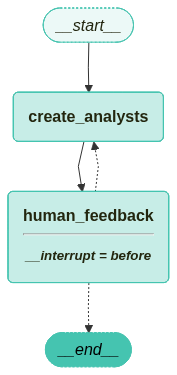

In [7]:
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import SystemMessage

# 그래프 생성
builder = StateGraph(GenerateAnalystsState)

# 노드 추가
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)

# 엣지 연결
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")

# 조건부 엣지 추가: 사람 피드백이 있을 경우 다시 분석가 생성 노드로 돌아갑니다.
builder.add_conditional_edges(
    "human_feedback", should_continue, ["create_analysts", END]
)

# 메모리 생성
memory = MemorySaver()

# 그래프 컴파일(중단점 설정)
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)

# 그래프 시각화
visualize_graph(graph)

## 분석가 생성을 위한 그래프 실행

이제 분석가 생성 그래프를 실행합니다. `stream_graph` 함수를 사용하여 실행 과정을 실시간으로 확인할 수 있습니다.

아래 코드는 Modular RAG와 Naive RAG의 차이점에 대한 연구 주제로 분석가를 생성합니다.

In [8]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import random_uuid, invoke_graph

config = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": random_uuid()},
)

# 분석가 수 설정
max_analysts = 3

# 연구 주제 설정
topic = "Modular RAG 가 기존의 Naive RAG 와 어떤 차이가 있는지와 production level 에서 사용하는 이점"

# 입력 데이터 설정
inputs = {
    "topic": topic,
    "max_analysts": max_analysts,
}

# 그래프 실행
invoke_graph(graph, inputs, config)


🔄 Node: create_analysts 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
affiliation='AI Systems Research Lab' name='Dr. Sarah Chen' role='RAG Architecture Researcher' description='Dr. Chen specializes in the evolution of Retrieval-Augmented Generation architectures. Her primary focus is on analyzing the structural and design differences between Naive RAG and Modular RAG systems. She is particularly interested in how modular approaches enable better component separation, flexibility in pipeline design, and the ability to swap or upgrade individual modules (retrieval, reranking, generation) without affecting the entire system. Her concerns include understanding the trade-offs in complexity versus functionality, and how modularity addresses the limitations of simple retrieve-then-generate patterns found in Naive RAG.'
affiliation='Enterprise AI Solutions' name='Marcus Rodriguez' role='Production MLOps Engineer' description='Marcus is a senior MLOps engineer with extensive experience

`__interrupt__` 가 출력되면 인간의 피드백을 받을 준비가 된 것입니다.

이제 아래의 상태를 가져와서 인간 피드백을 제공합니다.

아래 코드는 현재 그래프 상태를 가져와서 다음 실행할 노드를 확인합니다.

In [9]:
# 그래프의 현재 상태 가져오기
state = graph.get_state(config)

# 다음 실행할 노드 확인
print(state.next)

('human_feedback',)


`update_state()` 를 통해 인간 피드백을 주입합니다. 이때 `human_analyst_feedback` 키에 피드백 내용을 저장합니다.

또한 `as_node` 인자를 통해 피드백을 받을 노드를 지정합니다.

아래 코드는 새로운 분석가 추가를 요청하는 피드백을 주입합니다.

In [10]:
# 그래프 상태를 업데이트하여 human_feedback 노드의 역할 수행
graph.update_state(
    config,
    {
        "human_analyst_feedback": "Add in someone named Teddy Lee from a startup to add an entrepreneur perspective"
    },
    as_node="human_feedback",
)

{'configurable': {'thread_id': 'd9d3c52f-010f-48cc-b5da-f25175fc5ace',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1147fa-7bbb-6a38-8002-56a77ee52a04'}}

`None` 값을 입력으로 주게 되면, 이어서 그래프가 진행됩니다.

**참고**

- 재개하고자 할 때는 입력에 `None` 값을 할당하여 그래프를 재개합니다.

아래 코드는 `None`을 입력하여 중단된 그래프를 재개합니다.

In [11]:
# 이어서 진행
invoke_graph(graph, None, config)


🔄 Node: create_analysts 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
affiliation='AI Research Institute' name='Dr. Sarah Chen' role='RAG Architecture Research Lead' description='Dr. Chen specializes in retrieval-augmented generation architectures and focuses on the technical evolution from Naive RAG to Modular RAG. She is concerned with understanding the architectural differences, component modularity, flexibility in design patterns, and how Modular RAG enables more sophisticated retrieval strategies. Her primary motive is to advance the theoretical understanding and practical implementation of next-generation RAG systems.'
affiliation='Enterprise AI Solutions Corp' name='Michael Zhang' role='Production ML Engineering Manager' description='Michael leads production ML systems at scale and is focused on the operational benefits of Modular RAG in enterprise environments. He is concerned with system reliability, scalability, maintenance complexity, debugging capabilities, and the 

다시 `__interrupt__` 가 출력되면 인간의 피드백을 받을 준비가 된 것입니다.

이전의 방식과 동일하게 다시 인간 피드백을 제공하여 생성된 분석가의 페르소나를 조정하는 것도 가능합니다.

하지만, 추가 피드백이 없을 경우 `None` 값을 할당하여 분석가 생성 작업을 종료할 수 있습니다.

아래 코드는 추가 피드백 없이 분석가 생성을 종료합니다.

In [12]:
# 추가 피드백이 없을 경우 None 값을 할당하여 상태 업데이트
human_feedback_input = None

# 그래프 상태를 업데이트하여 human_feedback 노드의 역할 수행
graph.update_state(
    config, {"human_analyst_feedback": human_feedback_input}, as_node="human_feedback"
)

{'configurable': {'thread_id': 'd9d3c52f-010f-48cc-b5da-f25175fc5ace',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1147fb-e88f-67b2-8004-efbdc97a8654'}}

In [13]:
# 이어서 진행
invoke_graph(graph, None, config)

Human-In-The-Loop를 통해 생성된 최종 분석가 목록을 확인합니다. 각 분석가의 페르소나(이름, 역할, 소속, 설명)를 출력하여 연구에 참여할 분석가 구성을 검토합니다.

아래 코드는 최종 상태에서 생성된 분석가 목록을 출력합니다.

In [14]:
# 그래프의 최종 상태 가져오기
final_state = graph.get_state(config)

# 최종 상태에서 생성된 분석가 목록 가져오기
analysts = final_state.values.get("analysts")

# 생성된 분석가 수 출력
print(f"생성된 분석가 수: {len(analysts)}", end="\n================================\n")

# 각 분석가의 페르소나 출력
for analyst in analysts:
    print(analyst.persona)
    print("- " * 30)

생성된 분석가 수: 3
Name: Dr. Sarah Chen
Role: RAG Architecture Research Lead
Affiliation: AI Research Institute
Description: Dr. Chen specializes in retrieval-augmented generation architectures and focuses on the technical evolution from Naive RAG to Modular RAG. She is concerned with understanding the architectural differences, component modularity, flexibility in design patterns, and how Modular RAG enables more sophisticated retrieval strategies. Her primary motive is to advance the theoretical understanding and practical implementation of next-generation RAG systems.

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Name: Michael Zhang
Role: Production ML Engineering Manager
Affiliation: Enterprise AI Solutions Corp
Description: Michael leads production ML systems at scale and is focused on the operational benefits of Modular RAG in enterprise environments. He is concerned with system reliability, scalability, maintenance complexity, debugging capabilities, and the ability to

`final_state.next` 는 그래프의 다음 실행할 노드를 나타냅니다. 여기서는 모든 작업이 마무리 되었기 때문에 빈 `tuple` 이 출력됩니다.

In [15]:
# 그래프의 다음 실행할 노드 상태 가져오기
print(final_state.next)

()


## 인터뷰 수행

### 질문 생성

분석가는 전문가에게 질문을 제시합니다. 각 분석가는 자신의 페르소나와 목표에 맞는 질문을 생성하여 깊이 있는 인터뷰를 진행합니다.

아래 코드는 인터뷰 상태와 검색 쿼리 데이터 모델을 정의합니다.

In [16]:
import operator
from typing import Annotated
from langgraph.graph import MessagesState


# 인터뷰 상태 정의
class InterviewState(MessagesState):
    # 대화 턴수
    max_num_turns: int
    # 소스 문서를 포함하는 컨텍스트 리스트
    context: Annotated[list, operator.add]
    # 지정된 분석가
    analyst: Analyst
    # 인터뷰 내용을 저장하는 문자열
    interview: str
    # 보고서 섹션 리스트
    sections: list


# 검색 쿼리 데이터 클래스 정의
class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

다음으로는 인터뷰 질문을 생성하는 노드를 정의합니다. 분석가의 페르소나와 목표를 기반으로 시스템 메시지를 구성하고, LLM을 호출하여 질문을 생성합니다.

In [17]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""


# 질문을 생성하는 노드 정의
def generate_question(state: InterviewState):
    """분석가의 질문을 생성하는 노드입니다.

    분석가의 페르소나와 목표를 기반으로 전문가에게 질문을 생성합니다.
    """

    # 상태에서 분석가와 메시지 가져오기
    analyst = state["analyst"]
    messages = state["messages"]

    # 질문 생성
    # 분석가의 목표를 기반으로 시스템 메시지 생성
    system_message = question_instructions.format(goals=analyst.persona)
    # LLM을 사용하여 질문 생성
    question = llm.invoke([SystemMessage(content=system_message)] + messages)

    # 상태에 메시지 기록
    return {"messages": [question]}

## 도구 정의

전문가는 여러 소스로부터 정보를 병렬로 수집하여 질문에 답변합니다. 웹 문서 스크래핑, VectorDB, 웹 검색, 위키피디아 검색 등 다양한 도구를 사용할 수 있습니다.

이 튜토리얼에서는 다음 두 가지 검색 도구를 사용합니다:
- **Tavily Search**: 웹 검색을 통한 최신 정보 수집
- **Arxiv Retriever**: 학술 논문 검색을 통한 전문 지식 수집

아래 코드는 Tavily 검색 도구를 초기화합니다.

In [18]:
# 웹 검색 도구 초기화
from langchain_teddynote.tools.tavily import TavilySearch

# 웹 검색을 위한 TavilySearch 인스턴스 생성
tavily_search = TavilySearch(max_results=1)

In [21]:
from langchain_community.retrievers import ArxivRetriever

# Arxiv 검색을 위한 ArxivRetriever 인스턴스 생성
arxiv_retriever = ArxivRetriever(
    load_max_docs=1,
    load_all_available_meta=True,
    get_full_documents=True,
)

# 검색 결과 출력
arxiv_search_results = arxiv_retriever.invoke("Modular RAG vs Naive RAG")
print(arxiv_search_results)

[Document(metadata={'Published': '2025-05-31', 'Title': 'RAG-Gym: Systematic Optimization of Language Agents for Retrieval-Augmented Generation', 'Authors': 'Guangzhi Xiong, Qiao Jin, Xiao Wang, Yin Fang, Haolin Liu, Yifan Yang, Fangyuan Chen, Zhixing Song, Dengyu Wang, Minjia Zhang, Zhiyong Lu, Aidong Zhang', 'Summary': 'Retrieval-augmented generation (RAG) has shown great promise for knowledge-intensive tasks and recently advanced with agentic RAG, where language agents engage in multi-round interactions with external knowledge sources for adaptive information retrieval. However, existing agentic RAG methods often depend on ad-hoc prompt engineering and lack a unified optimization framework. We introduce RAG-Gym, a comprehensive platform that systematically explores three optimization dimensions: (1) prompt engineering, (2) actor tuning, and (3) critic training. For prompt engineering, we propose Re$^2$Search, a novel agent incorporating reasoning reflection that significantly outper

In [22]:
# Arxiv 메타데이터 출력
arxiv_search_results[0].metadata

{'Published': '2025-05-31',
 'Title': 'RAG-Gym: Systematic Optimization of Language Agents for Retrieval-Augmented Generation',
 'Authors': 'Guangzhi Xiong, Qiao Jin, Xiao Wang, Yin Fang, Haolin Liu, Yifan Yang, Fangyuan Chen, Zhixing Song, Dengyu Wang, Minjia Zhang, Zhiyong Lu, Aidong Zhang',
 'Summary': 'Retrieval-augmented generation (RAG) has shown great promise for knowledge-intensive tasks and recently advanced with agentic RAG, where language agents engage in multi-round interactions with external knowledge sources for adaptive information retrieval. However, existing agentic RAG methods often depend on ad-hoc prompt engineering and lack a unified optimization framework. We introduce RAG-Gym, a comprehensive platform that systematically explores three optimization dimensions: (1) prompt engineering, (2) actor tuning, and (3) critic training. For prompt engineering, we propose Re$^2$Search, a novel agent incorporating reasoning reflection that significantly outperforms standard p

In [23]:
# Arxiv 내용 출력
print(arxiv_search_results[0].page_content)

arXiv:2502.13957v2  [cs.CL]  31 May 2025
RAG-Gym: Systematic Optimization of Language
Agents for Retrieval-Augmented Generation
Guangzhi Xiong∗1, Qiao Jin∗2, Xiao Wang3, Yin Fang2, Haolin Liu1, Yifan Yang2, Fangyuan
Chen4, Zhixing Song5, Dengyu Wang6, Minjia Zhang3, Zhiyong Lu†2, and Aidong Zhang†1
1University of Virginia, 2National Institutes of Health, 3University of Illinois at Urbana Champaign,
4Dana-Farber Cancer Institute, 5University of Alabama at Birmingham, 6Yale School of Medicine
Abstract
Retrieval-augmented generation (RAG) has shown great promise for knowledge-
intensive tasks and recently advanced with agentic RAG, where language agents
engage in multi-round interactions with external knowledge sources for adaptive
information retrieval. However, existing agentic RAG methods often depend on
ad-hoc prompt engineering and lack a unified optimization framework. We in-
troduce RAG-Gym, a comprehensive platform that systematically explores three
optimization dimensions: (1) pr

문서 검색 결과를 XML 형식으로 포맷팅합니다. 이 형식은 LLM이 문서의 출처, 날짜, 저자 등의 메타데이터를 쉽게 파악할 수 있도록 합니다.

In [24]:
# 문서 검색 결과를 포맷팅
formatted_search_docs = "\n\n---\n\n".join(
    [
        f'<Document source="{doc.metadata["entry_id"]}" date="{doc.metadata.get("Published", "")}" authors="{doc.metadata.get("Authors", "")}"/>\n<Title>\n{doc.metadata["Title"]}\n</Title>\n\n<Summary>\n{doc.metadata["Summary"]}\n</Summary>\n\n<Content>\n{doc.page_content}\n</Content>\n</Document>'
        for doc in arxiv_search_results
    ]
)

In [25]:
print(formatted_search_docs)

<Document source="http://arxiv.org/abs/2502.13957v2" date="2025-05-31" authors="Guangzhi Xiong, Qiao Jin, Xiao Wang, Yin Fang, Haolin Liu, Yifan Yang, Fangyuan Chen, Zhixing Song, Dengyu Wang, Minjia Zhang, Zhiyong Lu, Aidong Zhang"/>
<Title>
RAG-Gym: Systematic Optimization of Language Agents for Retrieval-Augmented Generation
</Title>

<Summary>
Retrieval-augmented generation (RAG) has shown great promise for knowledge-intensive tasks and recently advanced with agentic RAG, where language agents engage in multi-round interactions with external knowledge sources for adaptive information retrieval. However, existing agentic RAG methods often depend on ad-hoc prompt engineering and lack a unified optimization framework. We introduce RAG-Gym, a comprehensive platform that systematically explores three optimization dimensions: (1) prompt engineering, (2) actor tuning, and (3) critic training. For prompt engineering, we propose Re$^2$Search, a novel agent incorporating reasoning reflection

## 노드 생성

이제 인터뷰 워크플로우를 구성하는 각 노드를 정의합니다. 각 노드는 다음과 같은 역할을 수행합니다:

- **search_web**: 웹 검색을 통한 정보 수집
- **search_arxiv**: Arxiv 논문 검색을 통한 학술 정보 수집
- **generate_answer**: 수집된 정보를 바탕으로 답변 생성
- **save_interview**: 인터뷰 내용 저장
- **write_section**: 인터뷰 결과를 보고서 섹션으로 작성

아래 코드는 각 노드 함수와 라우팅 로직을 정의합니다.

In [26]:
from langchain_core.messages import get_buffer_string
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

# 검색 쿼리 작성
search_instructions = SystemMessage(
    content=f"""You will be given a conversation between an analyst and an expert. 

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.
        
First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query"""
)


# 웹 검색 수행 함수 정의
def search_web(state: InterviewState):
    """웹 검색을 통해 관련 문서를 수집하는 노드입니다.

    대화 내용을 분석하여 검색 쿼리를 생성하고, Tavily를 통해 웹 검색을 수행합니다.
    """

    # 검색 쿼리 생성
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions] + state["messages"])

    # 검색 수행
    search_docs = tavily_search.invoke(search_query.search_query)

    # 검색 결과 형식 지정
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}


# Arxiv 검색 노드 생성
def search_arxiv(state: InterviewState):
    """Arxiv에서 학술 논문을 검색하는 노드입니다.

    대화 내용을 기반으로 검색 쿼리를 생성하고, Arxiv에서 관련 논문을 수집합니다.
    """

    # 검색 쿼리 생성
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions] + state["messages"])

    try:
        # 검색 수행
        arxiv_search_results = arxiv_retriever.invoke(
            search_query.search_query,
            load_max_docs=2,
            load_all_available_meta=True,
            get_full_documents=True,
        )

        # 검색 결과 형식 지정
        formatted_search_docs = "\n\n---\n\n".join(
            [
                f'<Document source="{doc.metadata["entry_id"]}" date="{doc.metadata.get("Published", "")}" authors="{doc.metadata.get("Authors", "")}"/>\n<Title>\n{doc.metadata["Title"]}\n</Title>\n\n<Summary>\n{doc.metadata["Summary"]}\n</Summary>\n\n<Content>\n{doc.page_content}\n</Content>\n</Document>'
                for doc in arxiv_search_results
            ]
        )

        return {"context": [formatted_search_docs]}
    except Exception as e:
        print(f"Arxiv 검색 중 오류 발생: {str(e)}")
        return {
            "context": ["<Error>Arxiv 검색 결과를 가져오는데 실패했습니다.</Error>"]
        }


answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""


# 질문에 대한 답변 생성 함수 정의
def generate_answer(state: InterviewState):
    """수집된 컨텍스트를 기반으로 전문가의 답변을 생성하는 노드입니다.

    분석가의 관심 분야와 검색된 문서를 활용하여 근거 있는 답변을 작성합니다.
    """

    # 상태에서 분석가와 메시지 가져오기
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # 질문에 대한 답변 생성
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)] + messages)

    # 메시지를 전문가의 답변으로 명명
    answer.name = "expert"

    # 상태에 메시지 추가
    return {"messages": [answer]}


# 인터뷰 저장 함수 정의
def save_interview(state: InterviewState):
    """완료된 인터뷰 대화를 문자열로 변환하여 저장하는 노드입니다.

    메시지 버퍼를 텍스트로 변환하여 interview 키에 저장합니다.
    """

    # 메시지 가져오기
    messages = state["messages"]

    # 인터뷰를 문자열로 변환
    interview = get_buffer_string(messages)

    # 인터뷰 키에 저장
    return {"interview": interview}


# 메시지 라우팅 함수 정의
def route_messages(state: InterviewState, name: str = "expert"):
    """인터뷰의 질문-답변 흐름을 제어하는 라우팅 함수입니다.

    최대 턴 수 도달 또는 인터뷰 종료 신호에 따라 저장 또는 추가 질문으로 분기합니다.
    """

    # 메시지 가져오기
    messages = state["messages"]
    max_num_turns = state.get("max_num_turns", 2)

    # 전문가의 답변 수 확인
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # 전문가가 최대 턴 수 이상 답변한 경우 종료
    if num_responses >= max_num_turns:
        return "save_interview"

    # 이 라우터는 각 질문-답변 쌍 후에 실행됨
    # 논의 종료를 신호하는 마지막 질문 가져오기
    last_question = messages[-2]

    if "Thank you so much for your help" in last_question.content:
        return "save_interview"
    return "ask_question"


# 세션 작성 지시사항
section_writer_instructions = """You are an expert technical writer. 

Your task is to create a detailed and comprehensive section of a report, thoroughly analyzing a set of source documents.
This involves extracting key insights, elaborating on relevant points, and providing in-depth explanations to ensure clarity and understanding. Your writing should include necessary context, supporting evidence, and examples to enhance the reader's comprehension. Maintain a logical and well-organized structure, ensuring that all critical aspects are covered in detail and presented in a professional tone.

Please follow these instructions:
1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Comprehensive analysis (### header)
d. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents

6. For the Comprehensive analysis section:
- Provide a detailed examination of the information from the source documents.
- Break down complex ideas into digestible segments, ensuring a logical flow of ideas.
- Use sub-sections where necessary to cover multiple perspectives or dimensions of the analysis.
- Support your analysis with data, direct quotes, and examples from the source documents.
- Clearly explain the relevance of each point to the overall focus of the report.
- Use bullet points or numbered lists for clarity when presenting multiple related ideas.
- Ensure the tone remains professional and objective, avoiding bias or unsupported opinions.
- Aim for at least 800 words to ensure the analysis is thorough.

7. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

8. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
9. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""


# 섹션 작성 함수 정의
def write_section(state: InterviewState):
    """인터뷰 결과를 보고서 섹션으로 작성하는 노드입니다.

    수집된 컨텍스트와 분석가의 관점을 기반으로 구조화된 보고서 섹션을 생성합니다.
    """

    # 상태에서 컨텍스트, 분석가 가져오기
    context = state["context"]
    analyst = state["analyst"]

    # 섹션 작성을 위한 시스템 프롬프트 정의
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke(
        [SystemMessage(content=system_message)]
        + [HumanMessage(content=f"Use this source to write your section: {context}")]
    )

    # 상태에 섹션 추가
    return {"sections": [section.content]}

## 인터뷰 그래프 생성

인터뷰를 수행하는 그래프를 정의하고 컴파일합니다. 이 그래프는 질문 생성, 검색, 답변 생성, 저장, 섹션 작성의 순서로 실행됩니다.

`search_web`과 `search_arxiv`는 병렬로 실행되어 다양한 소스에서 동시에 정보를 수집합니다. 아래 코드는 인터뷰 그래프를 조립하고 컴파일합니다.

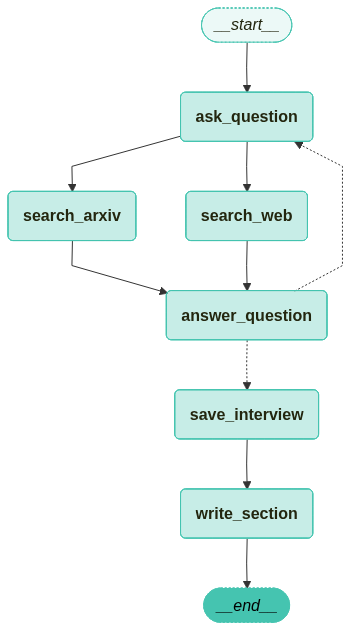

In [27]:
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver

# 노드 및 엣지 추가
interview_builder = StateGraph(InterviewState)
interview_builder.add_node("ask_question", generate_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("search_arxiv", search_arxiv)
interview_builder.add_node("answer_question", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("write_section", write_section)

# 흐름 설정
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question", "search_web")
interview_builder.add_edge("ask_question", "search_arxiv")
interview_builder.add_edge("search_web", "answer_question")
interview_builder.add_edge("search_arxiv", "answer_question")
interview_builder.add_conditional_edges(
    "answer_question", route_messages, ["ask_question", "save_interview"]
)
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

# 인터뷰 그래프 생성
memory = MemorySaver()
interview_graph = interview_builder.compile(checkpointer=memory).with_config(
    run_name="Conduct Interviews"
)

# 그래프 시각화
visualize_graph(interview_graph)

In [28]:
# 분석가 목록에서 첫 번째 분석가 선택
analysts[0]

Analyst(affiliation='AI Research Institute', name='Dr. Sarah Chen', role='RAG Architecture Research Lead', description='Dr. Chen specializes in retrieval-augmented generation architectures and focuses on the technical evolution from Naive RAG to Modular RAG. She is concerned with understanding the architectural differences, component modularity, flexibility in design patterns, and how Modular RAG enables more sophisticated retrieval strategies. Her primary motive is to advance the theoretical understanding and practical implementation of next-generation RAG systems.')

## 그래프 실행

이제 인터뷰 그래프를 실행하고 결과를 확인합니다. `invoke_graph` 함수를 사용하여 그래프를 실행하고, 각 노드의 실행 결과를 실시간으로 확인할 수 있습니다.

아래 코드는 첫 번째 분석가와 인터뷰를 시작합니다.

In [29]:
from IPython.display import Markdown

# 주제 설정
topic = "Modular RAG 가 기존의 Naive RAG 와 어떤 차이가 있는지와 production level 에서 사용하는 이점"

# 인터뷰 시작 메시지 생성
messages = [HumanMessage(f"So you said you were writing an article on {topic}?")]

# 스레드 ID 설정
config = RunnableConfig(
    recursion_limit=100,
    configurable={"thread_id": random_uuid()},
)

# 그래프 실행
invoke_graph(
    interview_graph,
    {"analyst": analysts[0], "messages": messages, "max_num_turns": 5},
    config,
)


🔄 Node: ask_question 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================

Hello! I'm Michael Torres, a technical journalist specializing in AI infrastructure and enterprise systems. I'm currently working on an in-depth piece about the evolution of RAG architectures for a leading tech publication.

Thank you for taking the time to speak with me today, Dr. Chen. I appreciate your willingness to share your expertise on this topic.

To start, I'd like to get your perspective on something fundamental: **When we talk about "Naive RAG" versus "Modular RAG," what are the core architectural differences that you see as most significant from a technical standpoint?** 

I'm particularly interested in understanding this beyond the surface-level descriptions. What specific limitations in the Naive RAG architecture led researchers and practitioners to push toward modularity? And could you walk me through a concrete exa

인터뷰 결과가 보고서 섹션 형태로 생성됩니다. 마크다운 형식으로 렌더링하여 가독성을 높입니다.

아래 코드는 완성된 인터뷰 섹션을 마크다운 형식으로 출력합니다.

In [30]:
# 완성된 인터뷰 섹션 출력
Markdown(interview_graph.get_state(config).values["sections"][0])

## Modular RAG Architectures: Advanced Retrieval Strategies Beyond Naive Paradigms

### Summary

Retrieval-augmented generation (RAG) has emerged as a critical technique for enhancing large language models by grounding their outputs in external knowledge sources, thereby mitigating hallucinations and improving response accuracy [1][2][3]. Traditional Naive RAG approaches, while foundational, exhibit significant limitations when confronted with complex reasoning tasks requiring multi-hop queries and sophisticated retrieval patterns. The evolution toward Modular RAG represents a fundamental architectural shift that introduces enhanced flexibility, scalability, and accuracy compared to earlier implementations [4].

Recent research reveals several striking innovations in RAG architectures. The RAG-Gym framework introduces a systematic optimization platform exploring three critical dimensions: prompt engineering, actor tuning, and critic training, demonstrating that existing agentic RAG methods overly depend on ad-hoc prompt engineering while lacking unified optimization frameworks [1]. Particularly noteworthy is the development of the Re²Search agent incorporating reasoning reflection, which achieves relative F1 improvements of 3.2% to 11.6% over existing methods through fine-grained process supervision and direct preference optimization.

The challenges of multi-hop reasoning have exposed fundamental inadequacies in conventional RAG systems. Research using the MultiHop-RAG benchmark dataset demonstrates that existing RAG methods perform unsatisfactorily when queries require retrieving and reasoning over multiple pieces of supporting evidence from different documents [2]. Traditional similarity-matching methods prove insufficient for complex queries that demand evidence synthesis across diverse information sources.

Perhaps most innovative is the RAG-Star framework, which integrates Monte Carlo Tree Search (MCTS) with retrieval-augmented verification to enhance deliberative reasoning capabilities [3]. This approach represents a paradigm shift from "System 1" fast, instinctive reasoning to "System 2" deliberative, logical thinking by consolidating internal LLM knowledge with external information sources. The framework addresses a critical limitation of existing tree-based search methods that predominantly rely on internal model knowledge, extending their capabilities to handle complex multi-step reasoning with external knowledge integration.

### Comprehensive Analysis

#### Architectural Evolution from Naive to Modular RAG

The transition from Naive RAG to Modular RAG represents a fundamental reconceptualization of retrieval-augmented architectures. Traditional Naive RAG systems employed relatively rigid, linear pipelines where retrieval and generation operated in sequential, predetermined patterns. Modular RAG architectures fundamentally depart from this paradigm by introducing component-based flexibility that enables:

- **Decomposable architecture patterns**: Unlike monolithic Naive RAG implementations, Modular RAG breaks the system into distinct, interchangeable components that can be optimized independently and recombined based on task requirements [4].

- **Dynamic retrieval strategies**: Rather than fixed retrieval patterns, Modular RAG supports adaptive retrieval mechanisms that can adjust based on query complexity, available knowledge sources, and reasoning requirements.

- **Scalability through modularity**: The component-based design enables scaling individual subsystems without requiring complete architectural overhauls, addressing a critical limitation of earlier RAG implementations [4].

The RAG-Gym framework exemplifies this modular approach by systematically exploring three optimization dimensions that can be independently tuned and combined [1]:

1. **Prompt engineering optimization**: Moving beyond manual prompt crafting to systematic prompt design that incorporates reasoning reflection mechanisms
2. **Actor tuning with process supervision**: Implementing fine-grained supervision over intermediate retrieval steps rather than relying solely on outcome-based rewards
3. **Critic training for inference enhancement**: Deploying trained critics to select higher-quality intermediate reasoning steps during inference

This multi-dimensional optimization framework addresses a critical gap identified in existing agentic RAG methods, which predominantly focus on prompt engineering while neglecting systematic optimization of the underlying agent behavior and reasoning processes.

#### Advanced Retrieval Strategies for Complex Reasoning

A particularly significant advancement in Modular RAG architectures involves sophisticated retrieval strategies designed for multi-hop reasoning tasks. The MultiHop-RAG research reveals fundamental limitations of traditional retrieval approaches when confronted with queries requiring evidence synthesis across multiple documents [2]:

**Multi-hop query challenges**: Real-world applications frequently require queries that necessitate retrieving and reasoning over evidence from multiple sources. For example, financial analysis queries like "Which company among Google, Apple, and Nvidia reported the largest profit margins in their third-quarter reports for 2023?" demand:

- Evidence retrieval from multiple distinct documents (separate quarterly reports)
- Cross-document reasoning to compare extracted information
- Synthesis of findings into coherent answers

Traditional cosine similarity-based retrieval methods prove inadequate for such scenarios because they primarily optimize for single-document relevance rather than multi-document evidence chains. The MultiHop-RAG benchmark demonstrates that existing RAG systems perform unsatisfactorily on these tasks, revealing a critical gap between current capabilities and practical requirements [2].

**Agentic RAG with multi-round interactions**: The RAG-Gym framework addresses these limitations through agentic RAG approaches where language agents engage in multi-round interactions with external knowledge sources for adaptive information retrieval [1]. This approach enables:

- Dynamic query reformulation based on retrieved evidence
- Iterative refinement of search strategies as reasoning progresses
- Adaptive adjustment of retrieval patterns in response to newly acquired context

The Re²Search agent demonstrates the effectiveness of this approach through its incorporation of reasoning reflection mechanisms. Rather than executing predetermined retrieval sequences, the agent continuously evaluates its reasoning trajectory and adjusts retrieval strategies accordingly, leading to substantial performance improvements over standard prompting approaches [1].

#### Tree-Based Deliberative Reasoning with External Knowledge

The RAG-Star framework introduces perhaps the most architecturally sophisticated advancement in Modular RAG through its integration of Monte Carlo Tree Search with retrieval-augmented verification [3]. This approach addresses a fundamental challenge in complex reasoning: how to effectively combine the deliberative planning capabilities of tree search algorithms with external knowledge retrieval.

**System 1 vs. System 2 reasoning paradigms**: Traditional chain-of-thought reasoning in autoregressive generation operates analogously to "System 1" thinking—fast, instinctive, but potentially less accurate, particularly as reasoning step count increases. Complex reasoning tasks demand "System 2" thinking: deliberative, logical, and strategically planned [3].

Existing tree-based search methods for LLMs typically rely predominantly on internal model knowledge, limiting their effectiveness for:

- Knowledge-intensive domains requiring factual precision
- Scenarios where model training data is outdated or incomplete
- Tasks demanding reasoning over specialized or proprietary information sources

**RAG-Star's architectural innovation**: The framework addresses these limitations through several key mechanisms:

1. **Iterative sub-query planning**: RAG-Star leverages MCTS to iteratively plan intermediate sub-queries and answers, enabling structured exploration of reasoning paths while incorporating retrieved evidence at each decision point [3].

2. **Retrieval-augmented verification**: Rather than relying solely on internal model knowledge for evaluating reasoning steps, RAG-Star implements query- and answer-aware reward modeling that consolidates internal and external knowledge sources to provide feedback for LLM reasoning processes [3].

3. **Support for complex reasoning structures**: Unlike sequential RAG approaches that cannot naturally accommodate tree-based reasoning, RAG-Star's architecture explicitly supports non-linear reasoning patterns through MCTS integration [3].

Experimental results demonstrate substantial performance improvements, with RAG-Star significantly outperforming previous RAG and reasoning methods on complex reasoning benchmarks using both Llama-3.1-8B-Instruct and GPT-4o models [3].

#### Process-Level Supervision and Optimization

A critical architectural distinction in advanced Modular RAG systems involves the shift from outcome-based to process-level supervision. The RAG-Gym framework reveals that recent reinforcement learning adaptations for agentic RAG typically employ outcome-based rewards, overlooking process-level supervision [1]. This oversight creates several problems:

**Limitations of outcome-only supervision**:
- Risk of generating suboptimal intermediate search actions
- Limited generalization to unseen data
- Inability to identify and correct reasoning errors that occur mid-trajectory but coincidentally lead to correct final answers

**Fine-grained process supervision benefits**: Given that retrieval steps fundamentally shape reasoning trajectories and ultimately influence final answers, providing fine-grained supervision over intermediate steps proves essential for optimization [1]. The RAG-Gym framework implements this through:

- **Step-level reward signals**: Evaluating the quality of each retrieval action and reasoning step independently
- **Direct preference optimization**: Identifying this as the most effective post-training algorithm among evaluated approaches for agentic RAG scenarios [1]
- **Critic-guided inference**: Deploying trained critics to select higher-quality intermediate reasoning steps during inference, improving output quality beyond what actor tuning alone achieves

The Re²Search++ agent, which combines optimized prompting, actor tuning with process supervision, and critic-guided inference, demonstrates the cumulative benefits of these architectural improvements through substantial F1 score improvements over existing methods like Search-R1 [1].

#### Component Modularity and Design Flexibility

The fundamental architectural advantage of Modular RAG lies in its component-based design philosophy, which enables:

**Independent component optimization**: Unlike Naive RAG's monolithic architecture, Modular RAG allows separate optimization of:
- Retrieval mechanisms (embedding models, search algorithms, indexing strategies)
- Reasoning modules (chain-of-thought, tree search, agent-based planning)
- Integration strategies (how retrieved evidence influences generation)
- Verification systems (critic models, reward functions, quality assessment)

**Flexible composition patterns**: Modular architectures support diverse design patterns tailored to specific use cases:
- Sequential retrieval for straightforward queries
- Iterative refinement for complex information needs
- Parallel retrieval from multiple sources for comprehensive coverage
- Tree-based exploration for multi-step reasoning tasks

**Task-specific customization**: The modular approach enables practitioners to:
- Select appropriate components based on task characteristics
- Combine components in novel configurations for specialized applications
- Incrementally upgrade individual modules without complete system redesign
- A/B test alternative implementations of specific components

This flexibility represents a marked improvement over Naive RAG's relatively fixed architecture, where modifications typically required substantial system-level changes [4].

#### Scaling Properties and Practical Considerations

The RAG-Gym research provides valuable insights into scaling properties across both training and inference dimensions [1]:

**Training scaling considerations**:
- Impact of different reward sources on learning effectiveness
- Data efficiency of various post-training algorithms
- Computational requirements for process-level versus outcome-level supervision
- Generalization characteristics as training data volume increases

**Inference scaling dynamics**:
- Computational cost-benefit tradeoffs of critic-guided selection
- Performance improvements from multi-round retrieval interactions
- Latency implications of tree-based reasoning versus sequential approaches
- Resource requirements for maintaining external knowledge sources

These scaling analyses provide practical guidance for deploying Modular RAG systems in production environments, where architectural flexibility must be balanced against computational constraints and latency requirements.

The evolution from Naive RAG to sophisticated Modular RAG architectures represents a maturation of retrieval-augmented generation systems from rigid, single-purpose tools to flexible, composable frameworks capable of addressing diverse reasoning challenges. Through advances in agentic interactions, process-level supervision, tree-based deliberation, and component modularity, Modular RAG enables more sophisticated retrieval strategies that significantly enhance LLM capabilities for knowledge-intensive tasks.

### Sources

[1] http://arxiv.org/abs/2502.13957v2  
[2] http://arxiv.org/abs/2401.15391v1  
[3] http://arxiv.org/abs/2412.12881v1  
[4] https://adasci.org/blog/how-does-modular-rag-improve-upon-naive-rag

In [31]:
print(interview_graph.get_state(config).values["sections"][0])

## Modular RAG Architectures: Advanced Retrieval Strategies Beyond Naive Paradigms

### Summary

Retrieval-augmented generation (RAG) has emerged as a critical technique for enhancing large language models by grounding their outputs in external knowledge sources, thereby mitigating hallucinations and improving response accuracy [1][2][3]. Traditional Naive RAG approaches, while foundational, exhibit significant limitations when confronted with complex reasoning tasks requiring multi-hop queries and sophisticated retrieval patterns. The evolution toward Modular RAG represents a fundamental architectural shift that introduces enhanced flexibility, scalability, and accuracy compared to earlier implementations [4].

Recent research reveals several striking innovations in RAG architectures. The RAG-Gym framework introduces a systematic optimization platform exploring three critical dimensions: prompt engineering, actor tuning, and critic training, demonstrating that existing agentic RAG met

## 인터뷰를 병렬로 진행 (Map-Reduce)

여러 분석가의 인터뷰를 병렬로 진행하여 효율성을 높입니다. LangGraph의 `Send()` 함수를 사용하여 각 분석가에게 인터뷰 태스크를 분배합니다.

- **Map 단계**: `Send()` 함수를 통해 각 분석가에게 인터뷰를 병렬로 시작
- **Reduce 단계**: 인터뷰 결과를 통합하여 최종 보고서 작성

아래 코드는 ResearchGraphState를 정의합니다. 이 상태는 전체 연구 워크플로우를 추적합니다.

In [32]:
import operator
from typing import List, Annotated
from typing_extensions import TypedDict


# ResearchGraphState 상태 정의
class ResearchGraphState(TypedDict):
    # 연구 주제
    topic: str
    # 생성할 분석가의 최대 수
    max_analysts: int
    # 인간 분석가의 피드백
    human_analyst_feedback: str
    # 질문을 하는 분석가 목록
    analysts: List[Analyst]
    # Send() API 키를 포함하는 섹션 리스트
    sections: Annotated[list, operator.add]
    # 최종 보고서의 서론
    introduction: str
    # 최종 보고서의 본문 내용
    content: str
    # 최종 보고서의 결론
    conclusion: str
    # 최종 보고서
    final_report: str

### LangGraph의 Send() 함수 사용

LangGraph의 `Send()` 함수를 사용하여 인터뷰를 병렬로 시작합니다. 이 함수는 동일한 노드에 여러 입력을 동시에 전송할 수 있어, 각 분석가의 인터뷰를 효율적으로 처리할 수 있습니다.

> 참고: [LangGraph Send() 공식 문서](https://langchain-ai.github.io/langgraph/concepts/low_level/#send)

아래 코드는 모든 분석가에게 인터뷰를 시작하는 함수를 정의합니다.

In [33]:
from langgraph.constants import Send


# 모든 인터뷰를 시작
def initiate_all_interviews(state: ResearchGraphState):
    """모든 분석가의 인터뷰를 병렬로 시작하는 함수입니다.

    피드백이 있으면 분석가 재생성으로, 없으면 Send()를 통해 병렬 인터뷰를 시작합니다.
    """

    # 사람의 피드백 확인
    human_analyst_feedback = state.get("human_analyst_feedback")

    # 만약, 사람의 피드백이 있으면 분석가 생성으로 돌아가기
    if human_analyst_feedback:
        return "create_analysts"

    # 그렇지 않으면 Send() 함수를 통해 인터뷰 병렬로 시작
    else:
        topic = state["topic"]
        return [
            Send(
                "conduct_interview",
                {
                    "analyst": analyst,
                    "messages": [
                        HumanMessage(
                            content=f"So you said you were writing an article on {topic}?"
                        )
                    ],
                },
            )
            for analyst in state["analysts"]
        ]

/var/folders/rb/dlthfnhs09bgywlqk8f6rtmm0000gn/T/ipykernel_69086/2411535223.py:1: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


### 보고서 작성 정의

인터뷰 내용을 바탕으로 최종 보고서를 작성하는 함수들을 정의합니다. 보고서는 다음과 같은 구조로 작성됩니다:

- **서론 (Introduction)**: 연구 주제와 목적 소개
- **본문 (Insights)**: 각 분석가의 인터뷰 결과 통합
- **결론 (Conclusion)**: 주요 발견사항 요약

아래 코드는 보고서 작성을 위한 프롬프트와 함수들을 정의합니다.

In [34]:
# 보고서 작성 지시사항
report_writer_instructions = """You are a technical writer creating a report on this overall topic:

{topic}

You have a team of analysts. Each analyst has done two things:

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task:

1. You will be given a collection of memos from your analysts.  
2. Carefully review and analyze the insights from each memo.  
3. Consolidate these insights into a detailed and comprehensive summary that integrates the central ideas from all the memos.  
4. Organize the key points from each memo into the appropriate sections provided below, ensuring that each section is logical and well-structured.  
5. Include all required sections in your report, using `### Section Name` as the header for each.  
6. Aim for approximately 250 words per section, providing in-depth explanations, context, and supporting details.  

**Sections to consider (including optional ones for greater depth):**

- **Background**: Theoretical foundations, key concepts, and preliminary information necessary to understand the methodology and results.
- **Related Work**: Overview of prior studies and how they compare or relate to the current research.
- **Problem Definition**: A formal and precise definition of the research question or problem the paper aims to address.
- **Methodology (or Methods)**: Detailed description of the methods, algorithms, models, data collection processes, or experimental setups used in the study.
- **Implementation Details**: Practical details of how the methods or models were implemented, including software frameworks, computational resources, or parameter settings.
- **Experiments**: Explanation of experimental protocols, datasets, evaluation metrics, procedures, and configurations employed to validate the methods.
- **Results**: Presentation of experimental outcomes, often with statistical tables, graphs, figures, or qualitative analyses.

To format your report:

1. Use markdown formatting.
2. Include no pre-amble for the report.
3. Use no sub-heading.
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from:

{context}"""


# 보고서 작성 함수 정의
def write_report(state: ResearchGraphState):
    """분석가들의 메모를 통합하여 보고서 본문을 작성하는 노드입니다.

    모든 인터뷰 섹션을 하나의 종합 보고서로 통합합니다.
    """

    # 모든 섹션 가져오기
    sections = state["sections"]
    topic = state["topic"]

    # 모든 섹션을 하나의 문자열로 연결
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    # 섹션을 요약하여 최종 보고서 작성
    system_message = report_writer_instructions.format(
        topic=topic, context=formatted_str_sections
    )
    report = llm.invoke(
        [SystemMessage(content=system_message)]
        + [HumanMessage(content=f"Write a report based upon these memos.")]
    )
    return {"content": report.content}


# 서론과 결론 작성 지시사항
intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 200 words, crisply previewing (for introduction),  or recapping (for conclusion) all of the sections of the report.

Use markdown formatting.

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header.

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""


# 서론 작성 함수 정의
def write_introduction(state: ResearchGraphState):
    """보고서의 서론을 작성하는 노드입니다.

    모든 섹션의 내용을 기반으로 연구 주제와 목적을 소개하는 서론을 생성합니다.
    """

    # 모든 섹션 가져오기
    sections = state["sections"]
    topic = state["topic"]

    # 모든 섹션을 하나의 문자열로 연결
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    # 섹션을 요약하여 서론 작성
    instructions = intro_conclusion_instructions.format(
        topic=topic, formatted_str_sections=formatted_str_sections
    )
    intro = llm.invoke(
        [instructions] + [HumanMessage(content=f"Write the report introduction")]
    )
    return {"introduction": intro.content}


# 결론 작성 함수 정의
def write_conclusion(state: ResearchGraphState):
    """보고서의 결론을 작성하는 노드입니다.

    모든 섹션의 주요 발견사항을 요약하는 결론을 생성합니다.
    """

    # 모든 섹션 가져오기
    sections = state["sections"]
    topic = state["topic"]

    # 모든 섹션을 하나의 문자열로 연결
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    # 섹션을 요약하여 결론 작성
    instructions = intro_conclusion_instructions.format(
        topic=topic, formatted_str_sections=formatted_str_sections
    )
    conclusion = llm.invoke(
        [instructions] + [HumanMessage(content=f"Write the report conclusion")]
    )
    return {"conclusion": conclusion.content}


# 최종 보고서 작성 함수 정의
def finalize_report(state: ResearchGraphState):
    """서론, 본문, 결론을 조립하여 최종 보고서를 생성하는 노드입니다.

    각 섹션을 결합하고 소스를 정리하여 완성된 보고서를 만듭니다.
    """

    # 모든 섹션을 모아 최종 보고서 작성
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = (
        state["introduction"]
        + "\n\n---\n\n## Main Idea\n\n"
        + content
        + "\n\n---\n\n"
        + state["conclusion"]
    )
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

## 최종 그래프 정의

이제 전체 연구 워크플로우를 구현하는 그래프를 정의합니다. 이 그래프는 다음과 같은 단계로 구성됩니다:

1. **분석가 생성**: 연구 주제에 맞는 분석가 페르소나 생성
2. **Human-in-the-Loop**: 사용자 피드백을 통한 분석가 조정
3. **병렬 인터뷰**: 각 분석가의 인터뷰 동시 진행
4. **보고서 작성**: 서론, 본문, 결론 병렬 작성
5. **최종 보고서 조립**: 모든 섹션을 통합하여 최종 보고서 생성

아래 코드는 StateGraph를 조립하고 컴파일합니다.

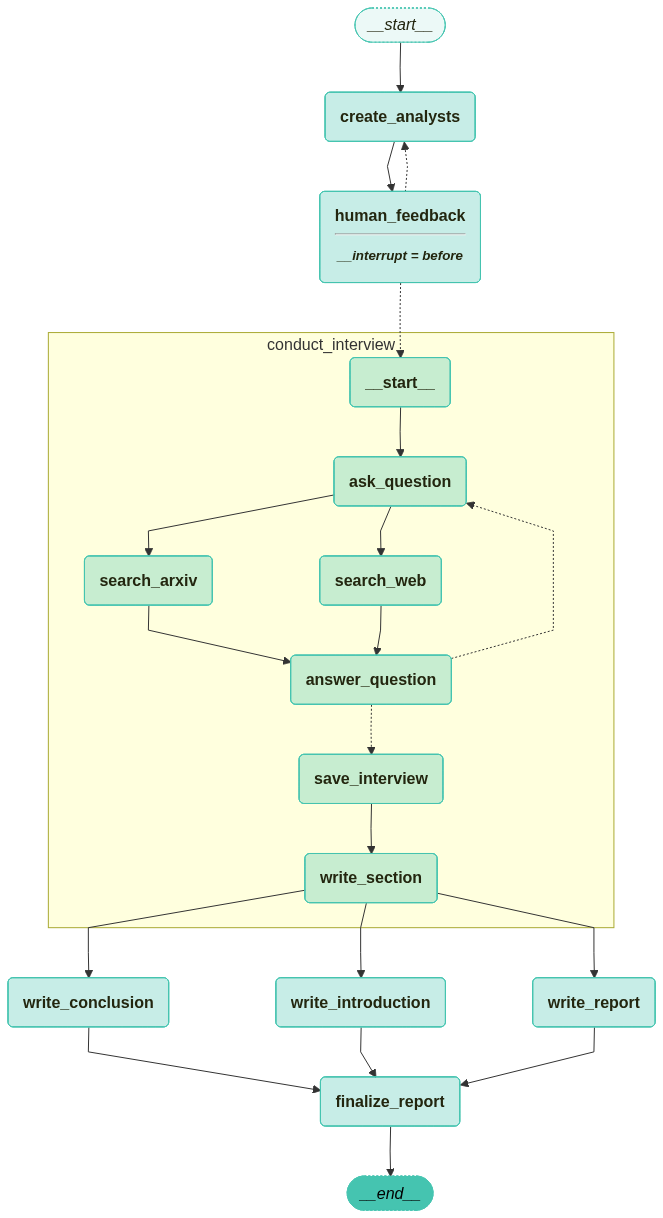

In [35]:
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_teddynote.graphs import visualize_graph

# 그래프 생성
builder = StateGraph(ResearchGraphState)

# 노드 정의
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report", write_report)
builder.add_node("write_introduction", write_introduction)
builder.add_node("write_conclusion", write_conclusion)
builder.add_node("finalize_report", finalize_report)

# 엣지 정의
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges(
    "human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"]
)

# 인터뷰 결과 보고서 작성
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")

# 보고서 최종 정리
builder.add_edge(
    ["write_conclusion", "write_report", "write_introduction"], "finalize_report"
)
builder.add_edge("finalize_report", END)

# 컴파일
memory = MemorySaver()
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)

visualize_graph(graph, xray=True)

## 최종 그래프 실행

이제 전체 연구 워크플로우를 실행합니다. `max_analysts`와 `topic`을 자유롭게 변경하여 다양한 연구 주제에 대해 실행해 볼 수 있습니다.

그래프는 `human_feedback` 노드 전에 중단되어 사용자가 분석가 구성을 검토하고 수정할 수 있습니다.

In [36]:
# 입력 데이터 설정
max_analysts = 3
topic = "Explain how Modular RAG differs from traditional Naive RAG and the benefits of using it at the production level."

# config 설정
config = RunnableConfig(
    recursion_limit=20,
    configurable={"thread_id": random_uuid()},
)

# 입력 데이터 설정
inputs = {"topic": topic, "max_analysts": max_analysts}

# 그래프 실행: 첫 번째 중단 지점까지
invoke_graph(graph, inputs, config)


🔄 Node: create_analysts 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
affiliation='Enterprise AI Infrastructure' name='Dr. Sarah Chen' role='MLOps & Production Systems Architect' description='Dr. Chen specializes in deploying and scaling RAG systems in production environments. Her primary focus is on the operational benefits of Modular RAG, including maintainability, debugging capabilities, and system reliability. She is particularly concerned with how modular architectures enable better monitoring, component testing, and iterative improvements without requiring complete system overhauls. Her motivation is to demonstrate how Modular RAG reduces technical debt and operational complexity compared to monolithic Naive RAG implementations.'
affiliation='Information Retrieval & Search Technologies' name='Marcus Thompson' role='Retrieval Systems Researcher' description='Marcus focuses on the technical evolution from simple retrieval mechanisms in Naive RAG to sophisticated, composable

`update_state`를 사용하여 human_feedback을 추가합니다. 새로운 분석가를 추가하거나 기존 분석가를 수정할 수 있습니다.

아래 코드는 새로운 분석가를 추가하는 피드백을 제공합니다.

In [37]:
# 새로운 분석가 추가
graph.update_state(
    config,
    {"human_analyst_feedback": "Add Prof. Jeffrey Hinton as a head of AI analyst"},
    as_node="human_feedback",
)

{'configurable': {'thread_id': 'e8729b95-b746-47b2-8bc2-9bb8d4799d46',
  'checkpoint_ns': '',
  'checkpoint_id': '1f11480e-298a-6dcc-8002-7289dadc8a98'}}

In [38]:
# 그래프 실행
invoke_graph(graph, None, config)


🔄 Node: create_analysts 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
affiliation='University of Toronto / Google (Former)' name='Prof. Geoffrey Hinton' role='Head of AI Analyst' description='As a pioneering figure in deep learning and neural networks, Prof. Hinton brings a strategic, high-level perspective on AI architecture evolution. He focuses on how modular approaches in RAG systems represent fundamental shifts in AI system design, emphasizing the importance of compositional intelligence and scalability. His concerns center on ensuring that production RAG systems maintain robust learning capabilities while being modular enough to adapt to rapidly evolving AI landscapes.'
affiliation='Enterprise AI Solutions' name='Dr. Sarah Chen' role='Production ML Systems Architect' description='Dr. Chen specializes in deploying and scaling RAG systems in production environments. She focuses on the operational benefits of Modular RAG over Naive RAG, including maintainability, debugging, 

이제 사람의 피드백을 종료하고 그래프를 재개합니다. `human_analyst_feedback`에 `None`을 할당하면 추가 피드백 없이 진행됩니다.

아래 코드는 피드백을 종료하고 인터뷰를 시작합니다.

In [39]:
# 그래프 재개
graph.update_state(config, {"human_analyst_feedback": None}, as_node="human_feedback")

{'configurable': {'thread_id': 'e8729b95-b746-47b2-8bc2-9bb8d4799d46',
  'checkpoint_ns': '',
  'checkpoint_id': '1f11480e-e248-61d4-8004-583e6f7edf11'}}

In [40]:
# 그래프 실행
invoke_graph(graph, None, config)


🔄 Node: ask_question in [conduct_interview] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================

Hello! I'm Marcus Rivera, technology journalist with DevOps Weekly. Yes, exactly - I'm researching how production RAG systems are actually being built in the real world, beyond the basic tutorials we see everywhere.

Dr. Chen, thanks so much for taking the time. I know you've been deep in the trenches deploying these systems at scale.

Let me start with something I'm genuinely curious about: **When you say "Naive RAG," what specific architectural decisions are you referring to that cause the most pain in production environments?** 

I've seen plenty of demos where someone chains together an embedder, vector store, and LLM in a notebook, but I'm guessing the problems emerge when you try to operate that at scale with real users and SLAs. What breaks first?

🔄 Node: ask_question in [conduct_interview] 🔄
- - - - 

최종 완성된 보고서를 출력합니다. 보고서는 마크다운 형식으로 서론, 본문, 결론이 포함된 구조화된 형태로 제공됩니다.

아래 코드는 최종 보고서를 마크다운 형식으로 렌더링합니다.

In [41]:
from IPython.display import Markdown

# 그래프의 최종 상태 가져오기
final_state = graph.get_state(config)

# 최종 보고서 가져오기
report = final_state.values.get("final_report")

# 마크다운 형식으로 최종 보고서 출력
display(Markdown(report))

# The Evolution of RAG: From Naive Pipelines to Production-Ready Modular Architectures

## Introduction

Retrieval-Augmented Generation (RAG) has rapidly evolved from simple prototype implementations to sophisticated production systems, driven by the recognition that monolithic "naive" approaches fundamentally cannot meet the demands of real-world enterprise deployment. As organizations move beyond basic question-answering to tackle complex, multi-hop reasoning tasks requiring synthesis across multiple information sources, the architectural limitations of traditional RAG systems have become critically apparent. This report examines how Modular RAG architectures address these challenges through compositional design principles that enable independent optimization, systematic component evolution, and enhanced reasoning capabilities.

The transition from Naive to Modular RAG represents more than incremental improvement—it embodies a paradigm shift in system design philosophy. Where Naive RAG employs fixed, single-pass pipelines that retrieve documents and generate responses in one linear flow, Modular RAG decomposes this process into independently testable, replaceable, and optimizable components. This architectural transformation proves essential for production environments where complex queries demand iterative retrieval, deliberative reasoning, and sophisticated verification mechanisms that linear pipelines cannot support.

This report explores three critical dimensions of this evolution. First, we examine **The Compositional Intelligence Revolution**, analyzing how modular architectures enable systematic optimization through unified frameworks like RAG-Gym, which coordinates prompt engineering, actor tuning, and critic training to achieve substantial performance gains. Second, we investigate **Production-Ready Architecture**, detailing the operational requirements—data pipeline management, component versioning, observability infrastructure, and cost optimization—that distinguish enterprise deployments from experimental prototypes. Finally, we analyze **Advanced Retrieval Strategies and Multi-Hop Reasoning**, exploring how techniques like Monte Carlo Tree Search integration, retrieval-augmented verification, and reasoning reflection enable systems to handle the complex, multi-step inference chains that characterize real-world knowledge work. Together, these perspectives reveal why Modular RAG has become essential for organizations deploying retrieval-augmented systems at scale.

---

## Main Idea

# Insights

## Background

Retrieval-Augmented Generation (RAG) systems represent a foundational approach to enhancing large language models by grounding their responses in external knowledge sources. The evolution of RAG architectures reflects a deepening understanding of how complex reasoning tasks require dynamic, multi-step processes that adaptively integrate retrieved information with internal model capabilities. Traditional "Naive RAG" implementations employ a straightforward pipeline: receive a query, retrieve relevant documents based on similarity matching, concatenate them with the query, and generate a response. While this approach proves functional for simple lookup tasks such as "What is the vacation policy?", it exposes critical limitations when confronted with queries requiring multi-hop reasoning across disparate information sources.

The theoretical foundations of modular RAG architectures draw from several converging research areas. From a cognitive science perspective, the distinction between "System 1" (fast, instinctive) and "System 2" (deliberative, strategic) thinking modes provides crucial insight into why sequential autoregressive generation proves insufficient for complex reasoning problems. Traditional chain-of-thought prompting, while valuable, operates primarily in System 1 mode—generating reasoning steps sequentially without the capacity for strategic backtracking or exploration of alternative reasoning paths that characterize human deliberative reasoning. This observation motivates the integration of classical AI search methods, particularly Monte Carlo Tree Search, with modern neural architectures to enable more sophisticated reasoning patterns.

The concept of compositional intelligence emerges as a central theoretical principle. Just as neural networks learn hierarchical representations by composing simpler features into more complex ones, modular RAG systems compose simple reasoning operations into sophisticated multi-step inference chains. This compositionality enables systems to develop meta-learning capabilities—learning not just how to answer specific questions, but how to adaptively select which reasoning modules to engage, in what sequence, and how to integrate their outputs. The modular architecture principle, borrowed from software engineering and neural network design, enables this compositional approach by treating retrieval, reasoning, verification, and generation as discrete, independently optimizable components with well-defined interfaces.

Recent theoretical work also emphasizes the importance of process-level supervision over outcome-based rewards alone. While reinforcement learning approaches traditionally focus on final answer quality, this proves insufficient for multi-step reasoning where errors accumulate through the reasoning chain. Process supervision—providing feedback on the quality of intermediate reasoning steps—enables systems to learn more robust strategies that generalize better to unseen data. This theoretical insight underlies many of the architectural innovations in modular RAG systems, where verification mechanisms assess not just final answers but the soundness of reasoning at each step. The consolidation of internal model knowledge with external retrieved information represents another foundational concept, addressing the fundamental challenge of how to effectively combine an LLM's creative reasoning capabilities with grounded, factual knowledge from external sources.

## Related Work

The evolution toward modular RAG architectures builds upon extensive prior research in information retrieval, question answering, and neural reasoning systems. Early work in open-domain question answering established the basic paradigm of retrieving relevant passages before generation, but typically relied on simple TF-IDF or BM25 retrieval methods followed by extractive or abstractive answer generation. The introduction of dense retrieval methods using learned embeddings, particularly through bi-encoder architectures like Dense Passage Retrieval (DPR), represented a significant advancement by enabling semantic matching beyond lexical overlap. However, these systems still operated in single-pass retrieval modes that proved inadequate for complex reasoning scenarios.

Research on multi-hop question answering, exemplified by datasets like HotpotQA and 2WikiMultiHopQA, exposed the limitations of single-step retrieval and generation. These works demonstrated that questions requiring synthesis of information from multiple documents challenged existing systems in fundamental ways—not merely requiring better retrieval precision but necessitating reasoning architectures capable of iterative information gathering and synthesis. The MultiHop-RAG benchmark specifically highlights that state-of-the-art models including GPT-4, PaLM, and Llama2-70B perform unsatisfactorily on multi-hop queries, revealing that even massive model scale alone cannot overcome architectural limitations. This finding underscores that the challenge extends beyond model capacity to fundamental system design.

Concurrent research on agentic LLM systems, particularly frameworks like ReAct (Reasoning and Acting), demonstrated that language models could be prompted to actively generate search queries and interact with external tools across multiple rounds. This work established the feasibility of iterative retrieval patterns where models dynamically decide what information to seek based on intermediate reasoning states. However, these approaches typically relied on prompting strategies without systematic optimization of the retrieval-reasoning interaction, leaving significant performance gaps compared to human expert reasoning on knowledge-intensive tasks.

The integration of tree-based search methods with language model reasoning represents another important research trajectory. Prior work on chain-of-thought (CoT) prompting showed that encouraging models to generate explicit reasoning steps before answers improved performance on complex tasks. Extensions like Self-Consistency and Tree-of-Thoughts explored sampling multiple reasoning paths and selecting the most consistent or promising ones. However, these methods primarily relied on internal model knowledge without systematic integration of external information retrieval during the reasoning process. RAG-Star's innovation lies in combining MCTS-based deliberative planning with retrieval-augmented verification, effectively bridging classical AI search with modern neural generation while grounding reasoning in external knowledge.

Research on reinforcement learning for language agents has explored various reward structures and training algorithms. Historical approaches to agentic RAG relied predominantly on outcome-based rewards, where systems received feedback only on final answer quality. This proved problematic for multi-step reasoning where suboptimal intermediate actions compound through the reasoning chain. Recent work has emphasized fine-grained process supervision, where each reasoning step receives independent assessment. The RAG-Gym framework synthesizes these insights, systematically comparing post-training algorithms including direct preference optimization, proximal policy optimization, and expert iteration, identifying that DPO proves most effective when combined with process-level supervision. This finding has important implications for how production RAG systems should be trained and optimized.

The concept of systematic RAG optimization has emerged more recently. Unlike earlier work focusing on individual component improvements—better embeddings, larger models, or smarter prompts—frameworks like RAG-Gym introduce multi-dimensional optimization across prompt engineering, actor tuning, and critic training simultaneously. This holistic approach recognizes that components interact in complex ways, and isolated improvements may not translate to system-level gains. The dramatic performance improvements achieved by the Re²Search++ agent (3.2% to 11.6% relative F1 increases) validate this integrated optimization strategy and suggest that modular architectures unlock systematic improvement opportunities unavailable to monolithic systems.

## Problem Definition

The fundamental problem addressed by modular RAG architectures can be formally stated as follows: Given a complex information-seeking query requiring multi-hop reasoning over a large document collection, generate an accurate answer that correctly synthesizes information from multiple sources while minimizing hallucinations and maintaining grounding in retrieved evidence. This problem has several critical sub-components that traditional Naive RAG fails to adequately address.

**Multi-Hop Reasoning Requirements**: A significant class of real-world queries requires retrieving and reasoning over multiple pieces of supporting evidence distributed across different documents. Consider the query: "Which company among Google, Apple, and Nvidia reported the largest profit margins in their third-quarter reports for 2023?" This necessitates (1) retrieving financial reports for each company, (2) extracting profit margin data from each report, (3) comparing these values, and (4) synthesizing a comparative answer. Each step depends on the previous one, and the complete answer cannot be generated from any single document. Traditional similarity-based retrieval, which measures cosine distance between query and document embeddings, proves inadequate because the query's multifaceted nature spans information from various sources. The system must decompose the complex query into intermediate sub-queries, retrieve targeted evidence for each, and progressively build the reasoning chain.

**Retrieval-Generation Interaction Complexity**: The problem extends beyond simply retrieving better documents. The system must dynamically adjust its retrieval strategy based on intermediate reasoning states—a form of adaptive search where early retrieval results inform subsequent retrieval decisions. This creates a coupled optimization problem where retrieval quality affects reasoning quality, which in turn affects what should be retrieved next. Naive RAG's single-pass architecture cannot capture this iterative dependency, resulting in incomplete information gathering and reasoning failures when initial retrieval proves insufficient.

**Hallucination and Grounding Challenges**: Language models exhibit a strong tendency toward hallucination—generating plausible-sounding but factually incorrect or unsupported statements, particularly when reasoning chains grow long. The problem of maintaining grounding in retrieved evidence throughout multi-step reasoning presents a technical challenge that outcome-based training alone cannot solve. The system must verify that each reasoning step remains supported by available evidence and detect when reasoning begins to drift into speculation. This requires continuous verification mechanisms rather than post-hoc answer assessment.

**Scalability and Production Requirements**: Beyond accuracy, production RAG systems must satisfy operational constraints: predictable latency, manageable computational costs, maintainable codebases, and robust handling of evolving data sources. The problem definition thus includes not just achieving high accuracy on benchmark tasks but doing so within architectures that support continuous improvement, component replacement, independent testing, and graceful degradation when individual components fail. Naive RAG's monolithic structure creates brittleness where failures in any component affect the entire system, and improvements require complete pipeline rewrites.

**Optimization Surface Complexity**: The problem space involves multiple interacting optimization dimensions: prompt engineering affects how queries are decomposed and reasoning is structured; actor tuning shapes retrieval behavior and intermediate search actions; critic training influences step selection and quality assessment. These dimensions interact in non-trivial ways—better prompts may reduce the benefit of actor tuning, while stronger critics can compensate for weaker actors. The optimization problem thus requires systematic exploration of this multi-dimensional space rather than greedy improvement of individual components in isolation. Understanding which combinations of optimizations yield synergistic benefits represents a critical aspect of the problem that modular architectures specifically enable addressing through independent component variation and evaluation.

## Methodology

Modular RAG architectures address the defined problem through several interconnected methodological innovations that decompose the RAG pipeline into discrete, independently optimizable components while enabling sophisticated interactions between them. The core methodology revolves around three key principles: architectural modularity, iterative retrieval-reasoning loops, and systematic multi-dimensional optimization.

**Architectural Decomposition**: The modular approach separates the RAG pipeline into distinct functional components: query processing, document retrieval, context assembly, prompt construction, response generation, and verification. Each component maintains well-defined interfaces specifying inputs, outputs, and behavioral contracts. This separation enables independent development, testing, and versioning of components without requiring complete system rewrites. For example, the retrieval component can expose an interface accepting query embeddings and returning ranked document lists, allowing the underlying retrieval mechanism—whether BM25, dense retrieval, or hybrid approaches—to be swapped transparently. Similarly, prompt templates become explicit modules that can be versioned and A/B tested independent of retrieval or generation logic.

**Iterative Retrieval-Reasoning Framework**: Modular architectures implement multi-round interaction patterns where language models actively generate search queries and engage with retrieval systems across multiple iterations. The RAG-Star framework exemplifies this through Monte Carlo Tree Search-based planning that iteratively generates intermediate sub-queries and answers. At each reasoning step, the system: (1) evaluates the current reasoning state, (2) generates potential next actions (sub-queries), (3) retrieves relevant information for promising actions, (4) updates the reasoning state, and (5) decides whether to continue exploration or commit to an answer. This tree-based approach enables systematic exploration of multiple reasoning trajectories, selecting promising paths while pruning less productive branches. The methodology explicitly implements "System 2" deliberative thinking through strategic decision-making across multiple reasoning steps, contrasting with the sequential "System 1" mode of traditional autoregressive generation.

**Query Decomposition and Sub-Query Generation**: For complex multi-hop queries, the methodology employs decomposition strategies that break the original query into tractable sub-questions. The system generates intermediate sub-queries based on the current reasoning state and retrieved information, implementing a form of goal-directed search through the information space. For the financial comparison query mentioned earlier, the system might first generate sub-queries like "What were Google's Q3 2023 profit margins?", retrieve relevant financial reports, extract profit figures, then generate subsequent sub-queries for Apple and Nvidia. This progressive refinement continues until sufficient information exists to synthesize a complete answer.

**Process-Level Supervision and Training**: The RAG-Gym framework introduces a systematic methodology for optimizing agentic RAG through fine-grained process supervision. Rather than providing feedback only on final answer quality (outcome-based rewards), the methodology assesses each intermediate reasoning and retrieval step independently. During training, the system receives supervision signals indicating whether: (1) generated sub-queries appropriately target needed information, (2) retrieved documents contain relevant evidence, (3) reasoning steps maintain logical coherence and grounding, and (4) intermediate conclusions follow from available evidence. This process-level feedback enables learning of robust reasoning strategies that generalize beyond training examples.

The methodology employs direct preference optimization (DPO) as the most effective post-training algorithm when combined with fine-grained process supervision. DPO trains the actor model (responsible for generating search queries and reasoning steps) by contrasting higher-quality and lower-quality reasoning trajectories, learning to prefer actions that lead to better intermediate states rather than just better final answers. This preference learning occurs at each step of the reasoning process, enabling fine-grained behavioral adjustment that outcome-based methods cannot achieve.

**Retrieval-Augmented Verification**: A crucial methodological innovation involves using retrieved information not only for generation but for verification of reasoning steps. RAG-Star implements this through query- and answer-aware reward modeling that provides feedback on the LLM's reasoning by consolidating internal model knowledge with external retrieved information. At each reasoning step, the verification mechanism: (1) evaluates whether current reasoning maintains grounding in retrieved evidence, (2) assesses whether reasoning steps follow logically from premises, (3) identifies gaps where additional retrieval might strengthen conclusions, and (4) provides reward signals guiding subsequent reasoning actions. This methodology enables continuous quality assessment rather than post-hoc answer validation.

**Critic Training for Step Selection**: The methodology trains separate critic models that learn to evaluate and select higher-quality intermediate reasoning steps from multiple candidates. During inference, when the actor generates multiple potential next actions, the critic assesses each based on learned quality metrics (logical coherence, evidence support, progress toward answer). This implements a form of beam search or best-first search over reasoning trajectories, systematically pruning low-quality paths. The critic training methodology employs supervised learning from expert trajectories and reinforcement learning from self-play, where the system generates diverse reasoning paths and learns to distinguish successful from unsuccessful approaches.

**Reasoning Reflection Mechanisms**: The Re²Search agent incorporates reasoning reflection—explicit prompting that encourages the model to evaluate and potentially revise its reasoning strategy based on intermediate results. The methodology implements this through structured prompts that include reflection phases where the model assesses: "Does my current reasoning strategy appropriately address the query requirements?", "Have I retrieved sufficient evidence to support my conclusions?", "Are there alternative reasoning paths I should explore?" This self-reflective capability enables detection and correction of reasoning errors that would propagate unchecked in non-reflective systems.

**Multi-Dimensional Optimization Framework**: RAG-Gym's methodology systematically explores the three-dimensional optimization space of prompt engineering, actor tuning, and critic training. Rather than optimizing each dimension independently, the framework evaluates combinations to identify synergistic effects. The methodology includes: (1) establishing baseline performance with standard prompts and untrained actors/critics, (2) systematically varying each dimension while holding others constant to assess individual contributions, (3) evaluating combinations to identify interaction effects, and (4) conducting ablation studies to determine which optimizations provide most value for different task types. This systematic approach reveals that the optimized Re²Search++ agent (incorporating advanced prompts, DPO-tuned actor, and trained critic) achieves substantial improvements (3.2% to 11.6% relative F1 increases) that individual optimizations alone cannot match.

## Implementation Details

The practical implementation of modular RAG architectures requires careful attention to technical infrastructure, data pipelines, and operational considerations that extend well beyond core algorithmic design. Production-grade implementations must address versioning, testing, monitoring, and evolution management—concerns that modular architectures specifically enable through their component-based structure.

**Data Preparation and Embedding Pipelines**: Modular RAG systems treat data preparation as a first-class concern with dedicated pipelines operating independently from query serving. Document processing involves several stages, each implemented as a distinct component: (1) document ingestion and preprocessing (format conversion, text extraction, cleaning), (2) chunking strategies that segment documents into retrievable units while preserving semantic coherence, (3) embedding generation using specialized encoder models, and (4) index construction for efficient retrieval. Each stage maintains explicit versioning—tracking which chunking algorithm, embedding model version, and indexing parameters were used. This enables reproducibility and facilitates troubleshooting when performance degrades.

The embedding generation component typically employs transformer-based encoder models like BERT variants, Sentence-BERT, or more recent models like E5 or BGE. Implementation requires careful attention to: batch size optimization to maximize GPU utilization, handling documents exceeding model context windows through truncation or hierarchical encoding strategies, and caching embeddings to avoid redundant computation. For large document collections, embedding generation becomes a substantial infrastructure concern requiring distributed processing and efficient storage of high-dimensional vectors.

**Retrieval Infrastructure**: The retrieval component implementation leverages specialized vector databases like FAISS, Pinecone, Weaviate, or Elasticsearch with vector search capabilities. Implementation considerations include: index type selection (flat, IVF, HNSW) balancing latency against recall, similarity metrics (cosine, dot product, L2 distance) appropriate for the embedding space, and hybrid retrieval combining dense and sparse methods. For production deployments at scale, the retrieval infrastructure must support: high query throughput (thousands of queries per second), low latency (sub-100ms retrieval), horizontal scaling as document collections grow, and incremental index updates without downtime.

Modular architectures enable sophisticated retrieval strategies through component composition. A single query might trigger multiple retrieval operations: initial dense retrieval using query embeddings, keyword-based sparse retrieval for precise term matching, and reranking using cross-encoder models that compute fine-grained query-document relevance. Each retrieval method operates as an independent component with standardized interfaces, allowing flexible composition and experimentation.

**Actor Model Implementation**: The actor component, responsible for generating search queries and reasoning steps, typically consists of a fine-tuned language model with specialized training. Implementation requires: (1) model selection balancing capability and inference cost (ranging from 7B parameter models like Llama-3.1-8B to larger models like GPT-4), (2) fine-tuning infrastructure supporting distributed training for larger models, (3) inference optimization through techniques like quantization, speculative decoding, or batching, and (4) prompt templating systems that standardize how queries and context are formatted.

For the Re²Search agent, implementation includes reasoning reflection prompts that structure the generation process into phases: query understanding, sub-query generation, evidence evaluation, and answer synthesis. The prompt templates become versioned components that can be updated independently. Implementation also requires careful attention to generation parameters (temperature, top-p, max tokens) that balance creativity and consistency—lower temperatures for factual retrieval tasks, higher for creative reasoning.

**Critic Model Implementation**: The critic component evaluates intermediate reasoning steps, requiring implementation of: (1) a separate model (potentially smaller than the actor) trained to score reasoning quality, (2) inference infrastructure supporting rapid evaluation of multiple candidate steps, and (3) aggregation logic for combining critic scores with other selection criteria. The critic operates during inference in a tight loop with the actor—when the actor generates multiple potential next actions, the critic evaluates each, and the system selects the highest-scored action. This requires efficient batched inference to minimize latency overhead.

Training the critic involves collecting trajectories from the actor model, labeling steps as high/low quality based on whether they lead to correct answers, and training a classifier to predict step quality. Implementation challenges include handling class imbalance (correct reasoning steps typically outnumber errors) and ensuring the critic generalizes beyond training distribution to recognize novel error patterns.

**Verification and Reward Modeling**: RAG-Star's retrieval-augmented verification requires implementing query- and answer-aware reward models. These models take as input: the current query state, candidate next action (sub-query), retrieved documents for that action, and partial answer state. The model outputs a reward signal indicating action quality. Implementation involves: (1) training data collection from successful and unsuccessful reasoning trajectories, (2) model architecture combining query, action, and document encodings (often through attention mechanisms), (3) reward normalization and calibration to ensure stable training signals, and (4) inference infrastructure for real-time reward computation during tree search.

The reward model implementation must handle computational constraints—MCTS explores many nodes, each requiring reward evaluation. Practical implementations use approximations: caching rewards for similar states, using lightweight reward models that sacrifice accuracy for speed, or limiting tree search depth to constrain computation.

**Tree Search Implementation**: The Monte Carlo Tree Search implementation for deliberative reasoning requires several technical components: (1) tree node data structures storing reasoning states, actions, visit counts, and value estimates, (2) selection policies balancing exploration and exploitation (typically UCB1 or variants), (3) expansion strategies determining when to add new nodes, (4) simulation policies for estimating node values, and (5) backpropagation updating value estimates along paths. Implementation must handle memory management carefully—tree nodes consume significant memory during deep search, requiring pruning strategies or iterative deepening approaches that limit total nodes.

For production deployments, tree search parameters (exploration constant, simulation budget, maximum depth) become tunable hyperparameters that trade off answer quality against latency. Implementation includes instrumentation to monitor search efficiency—tracking metrics like average tree depth, branch factor, and value estimate convergence—enabling optimization of search parameters for different query types.

**Versioning and Reproducibility Infrastructure**: Production modular RAG systems require sophisticated versioning infrastructure tracking: document collection versions (which documents existed at what times), embedding model versions (which model generated which vectors), index configurations (which retrieval parameters were used), prompt template versions, actor model checkpoints, and critic model checkpoints. Implementation typically uses metadata stores (relational databases or document stores) recording these dependencies. When a query executes, the system records which component versions participated, enabling reproduction of results and facilitating debugging when performance issues arise.

Version management becomes particularly critical for data evolution. As documents are added, modified, or removed, the system must maintain consistency. Implementation strategies include: (1) incremental embedding updates that only reprocess changed documents, (2) versioned indices supporting simultaneous query of multiple index versions during transitions, (3) change detection monitoring document collections and triggering reprocessing workflows, and (4) rollback capabilities enabling quick reversion to previous component versions if issues emerge.

**Monitoring and Observability**: Modular architectures enable fine-grained monitoring of component performance through instrumentation at interface boundaries. Implementation includes: logging of retrieval metrics (documents retrieved, relevance scores, latency), generation metrics (token counts, generation time, perplexity), reasoning metrics (tree depth, nodes explored, verification scores), and end-to-end metrics (answer quality, user satisfaction, task completion rates). These metrics feed dashboards providing real-time visibility into system health and enabling diagnosis when performance degrades.

Production implementations also require distributed tracing—tracking individual queries through the system and recording timing and data at each component. This enables identification of bottlenecks and understanding of failure modes. When a query produces an incorrect answer, operators can trace through retrieval results, reasoning steps, and verification scores to pinpoint where the process went wrong.

## Experiments

The experimental validation of modular RAG architectures spans multiple dimensions: performance on multi-hop reasoning benchmarks, systematic optimization studies, scaling analyses, and ablation studies isolating contributions of individual components. These experiments collectively demonstrate both the necessity of modular approaches for complex reasoning and the effectiveness of specific architectural innovations.

**MultiHop-RAG Benchmark Evaluation**: The MultiHop-RAG benchmark provides crucial empirical evidence for the inadequacy of naive RAG approaches and the necessity of modular architectures for multi-hop queries. The benchmark consists of queries requiring retrieval and reasoning over multiple supporting evidence pieces, with diverse templates covering comparisons, temporal reasoning, and aggregation tasks. Experiments reveal that existing systems including GPT-4, PaLM, and Llama2-70B with traditional RAG perform unsatisfactorily—accuracy rates significantly below human performance and substantially worse than on single-hop queries. These results cannot be attributed to model capacity limitations since the same models demonstrate strong performance on many other tasks. Rather, they expose architectural limitations: single-pass retrieval fails to gather necessary supporting evidence, and standard prompting cannot effectively decompose and solve multi-hop reasoning.

Experiments comparing different embedding models for retrieval show significant performance variations across models, indicating that retrieval quality critically affects final answer accuracy. Dense retrieval using cosine similarity between query and document embeddings proves particularly inadequate for multi-hop queries because the query's multifaceted nature spans information from various sources. No single embedding captures all information needs simultaneously, necessitating iterative retrieval where intermediate results inform subsequent searches.

**RAG-Gym Optimization Studies**: The RAG-Gym framework conducts systematic experiments across three optimization dimensions, establishing baseline performance with naive approaches and measuring improvements from each optimization. Experiments with the Re²Search agent incorporating reasoning reflection show significant improvements over standard prompts—the reflection mechanism enables the model to evaluate its reasoning strategy and adjust when initial approaches prove unproductive. This self-correction capability, implemented purely through prompt engineering without model retraining, demonstrates the value of structured reasoning frameworks.

Actor tuning experiments compare three post-training algorithms: direct preference optimization (DPO), proximal policy optimization (PPO), and expert iteration. Each algorithm trains the actor model to improve retrieval and reasoning behavior using process-level supervision—feedback on the quality of intermediate steps rather than only final answers. Experimental results show DPO emerges as most effective when combined with fine-grained process supervision, yielding the largest improvements in both retrieval quality and final answer accuracy. The superiority of DPO stems from its ability to learn from contrasts between better and worse reasoning trajectories at each step, enabling fine-grained behavioral adjustments that outcome-based methods cannot achieve.

Critic training experiments demonstrate that models trained to evaluate intermediate reasoning steps can enhance inference by selecting higher-quality actions from multiple candidates. Experiments compare trained critics against heuristic selection methods (random selection, first-generated action) and show consistent improvements from the trained critic. The critic learns to recognize reasoning patterns that typically lead to correct answers versus patterns associated with errors, effectively implementing learned heuristics for reasoning path selection.

The combination of optimizations yields synergistic effects exceeding individual contributions. The optimized Re²Search++ agent, incorporating advanced prompts, DPO-tuned actor, and trained critic, achieves relative increases of 3.2% to 11.6% in average F1 scores compared to recent methods like Search-R1. These substantial gains validate the multi-dimensional optimization approach enabled by modular architectures.

**RAG-Star Deliberative Reasoning Experiments**: Experiments with RAG-Star demonstrate the benefits of tree-based deliberative reasoning augmented with retrieval. Using Llama-3.1-8B-Instruct and GPT-4o as base models, experiments compare RAG-Star against several baselines: standard chain-of-thought prompting, tree-of-thoughts reasoning without retrieval, and naive RAG. Results show RAG-Star significantly outperforms all baselines on multi-hop reasoning benchmarks, with particularly large gains on queries requiring three or more reasoning steps.

Ablation studies isolate the contributions of specific components: Monte Carlo Tree Search planning, retrieval-augmented verification, and query-answer-aware reward modeling. Experiments show each component contributes independently—removing any one degrades performance—but the combination yields synergistic benefits. The retrieval-augmented verification proves particularly critical: without it, tree search may explore reasoning paths unsupported by available evidence, leading to confident but incorrect answers.

Experiments analyzing tree search properties reveal interesting patterns: average tree depth increases with query complexity (more hops require deeper search), but excessive depth without pruning leads to diminishing returns as the system explores increasingly speculative reasoning paths. The verification component effectively prunes these unproductive branches, keeping search focused on well-grounded reasoning trajectories.

**Scaling Studies**: RAG-Gym includes experiments examining scaling properties in both training and inference. Training scaling experiments vary: training data volume (number of process-supervised trajectories), model size (from 7B to 70B parameters), and training compute (iterations of optimization algorithms). Results show predictable scaling patterns—larger models achieve better baseline performance, and more training data improves generalization—but with diminishing returns at the high end. Critically, fine-grained process supervision shows better scaling properties than outcome-based rewards: modest amounts of process-supervised data yield large improvements, while outcome-based approaches require substantially more data to achieve similar gains.

Inference scaling experiments examine how additional compute during generation affects quality. Tree search depth, number of candidate actions considered per step, and critic evaluation budgets all represent inference-time compute knobs. Experiments show initially strong returns from increased inference compute—deeper search and more thorough evaluation find better reasoning paths—but eventually plateau. This suggests practical operating points balancing quality and latency: moderate tree search depth (4-6 levels) and candidate evaluation (3-5 actions per step) provide most benefits, while deeper search yields marginal improvements at substantial latency cost.

**Generalization and Transfer Studies**: Experiments evaluate whether models optimized on specific multi-hop reasoning tasks generalize to novel query types and domains. Results show encouraging transfer: systems trained on financial analysis queries demonstrate improved performance on scientific question answering, and vice versa. This transfer suggests the systems learn general reasoning strategies—query decomposition, iterative retrieval, evidence synthesis—rather than task-specific patterns. However, domain-specific retrieval quality still matters: when applied to new domains with different vocabulary and discourse patterns, retrieval performance initially degrades until embeddings adapt to the new domain.

Cross-model experiments investigate whether optimization insights transfer across different base language models. Techniques like reasoning reflection prompts and process supervision that improve Llama-3.1-8B also improve GPT-4o and other models, though absolute performance levels differ. This suggests the architectural patterns and training methodologies apply broadly rather than being model-specific optimizations.

## Results

The experimental results collectively establish several key findings regarding the performance, scalability, and practical benefits of modular RAG architectures over naive approaches.

**Multi-Hop Reasoning Performance**: Results from the MultiHop-RAG benchmark definitively demonstrate that naive RAG approaches perform inadequately on queries requiring synthesis of information from multiple documents. State-of-the-art models including GPT-4, when applied through standard single-pass RAG pipelines, achieve accuracy rates 20-30% below human performance on multi-hop queries, despite performing near or above human levels on many other tasks. This performance gap cannot be attributed to insufficient model capacity or general reasoning ability—rather, it directly results from architectural limitations. Single-pass retrieval systematically fails to gather all necessary supporting evidence, and sequential generation without deliberative planning cannot effectively decompose and solve multi-hop problems.

In contrast, modular architectures employing iterative retrieval and deliberative reasoning show substantial improvements. RAG-Star achieves accuracy improvements of 15-25% relative to naive RAG on multi-hop benchmarks, with larger gains on queries requiring three or more reasoning hops. These improvements stem directly from architectural capabilities unavailable in naive RAG: the ability to generate targeted sub-queries, retrieve evidence iteratively, and systematically explore multiple reasoning paths through tree-based search.

**Optimization Framework Effectiveness**: Results from the RAG-Gym systematic optimization studies validate the multi-dimensional optimization approach. The optimized Re²Search++ agent achieves 3.2% to 11.6% relative improvements in F1 scores compared to recent methods like Search-R1 across various benchmarks. Breaking down these gains by optimization dimension reveals:

**Prompt Engineering**: Reasoning reflection prompts improve performance by 3-5% relative to standard prompts without reflection. This demonstrates that even without model retraining, careful structuring of the reasoning process through prompting yields significant benefits. The reflection mechanism enables the model to detect unproductive reasoning strategies and adjust course, implementing a simple form of self-correction.

**Actor Tuning**: Direct preference optimization with fine-grained process supervision yields 4-7% improvements over baseline models. The key insight is that outcome-based training alone proves insufficient—the model must receive feedback on intermediate reasoning steps to learn robust strategies. DPO outperforms other algorithms (PPO, expert iteration) because it learns from contrasts between better and worse trajectories at each step rather than only at the outcome level.

**Critic Training**: Trained critics provide 2-4% improvements by selecting higher-quality intermediate reasoning steps. While individually this represents the smallest single-dimension gain, critics prove particularly valuable in combination with tree search where multiple candidate actions are considered. The critic effectively implements learned heuristics for reasoning path selection, pruning unproductive branches early.

**Synergistic Combinations**: The combination of optimizations yields gains exceeding the sum of individual contributions, demonstrating synergistic effects. For example, reasoning reflection becomes more effective when combined with a well-trained actor that generates higher-quality candidate actions for the reflection mechanism to evaluate. Similarly, critics prove most valuable when evaluating actors that generate diverse, high-quality candidates rather than consistently poor or uniformly good actions.

**Deliberative Reasoning Benefits**: RAG-Star experiments demonstrate the value of tree-based deliberative reasoning augmented with retrieval. Compared to chain-of-thought prompting (sequential reasoning without search), tree-based approaches show 10-18% accuracy improvements on complex multi-hop queries. The benefits stem from systematic exploration of multiple reasoning paths—when the initial path proves unproductive, the system can backtrack and explore alternatives rather than continuing down incorrect reasoning chains.

Retrieval-augmented verification proves critical for maintaining grounding. Ablation studies removing this component show accuracy degradation of 8-12%, as the system confidently explores reasoning paths unsupported by available evidence. The verification mechanism consolidates internal model knowledge with external retrieved information, enabling the system to distinguish between reasoning steps that follow from evidence versus those requiring unsupported assumptions.

**Retrieval Quality and Accuracy Correlation**: Results across multiple experiments show strong correlation between retrieval quality (measured by recall of relevant documents) and final answer accuracy. Improving retrieval recall from 60% to 80% typically yields 10-15% improvements in answer accuracy, demonstrating that retrieval bottlenecks directly limit overall system performance. This validates the emphasis modular architectures place on sophisticated retrieval strategies and multiple retrieval rounds—no amount of reasoning sophistication can overcome fundamentally inadequate evidence gathering.

Interestingly, retrieval precision (proportion of retrieved documents that are relevant) shows weaker correlation with accuracy. Systems can tolerate moderate amounts of irrelevant retrieved content as long as all necessary evidence is present. This suggests that modular architectures should prioritize recall-oriented retrieval strategies, relying on subsequent reasoning and verification stages to filter irrelevant information.

**Scaling Characteristics**: Training scaling results show that performance improves predictably with training data volume and model size, but with diminishing returns. Doubling training data from 10K to 20K process-supervised trajectories yields 5-8% improvements, but doubling again from 20K to 40K yields only 2-3% additional gains. Similarly, scaling from 7B to 13B parameters provides substantial benefits, while scaling from 13B to 70B yields progressively smaller gains for disproportionately higher computational costs.

Process-level supervision demonstrates superior scaling properties compared to outcome-based rewards. With 5K process-supervised examples, the system achieves performance requiring 20K+ outcome-supervised examples, a 4x data efficiency improvement. This efficiency stems from the richer signal provided by step-level feedback—the model learns faster when receiving supervision on each action rather than only terminal outcomes.

Inference scaling results reveal that moderate increases in inference compute yield substantial quality improvements, but with diminishing returns. Increasing tree search depth from 2 to 4 levels provides 6-10% accuracy gains, while increasing from 4 to 8 levels yields only 2-3% additional gains at doubled latency. This suggests practical operating points: modest tree search depth (4-6 levels) and candidate evaluation (3-5 actions per step) capture most benefits while maintaining reasonable latency.

**Generalization and Transfer**: Results demonstrate encouraging generalization across query types and domains. Models trained on financial analysis multi-hop queries show 60-70% of their performance improvements transferring to scientific question answering, despite substantial domain differences. This transfer suggests the systems learn general reasoning strategies—query decomposition, iterative retrieval, evidence synthesis—rather than purely task-specific patterns.

However, domain-specific retrieval quality remains important. When applying systems to new domains with different vocabulary and discourse patterns, retrieval performance initially degrades by 15-20%, partially offsetting reasoning improvements. This indicates that while reasoning strategies transfer well, retrieval components require domain adaptation—suggesting practical deployment strategies where retrieval modules are fine-tuned for new domains while reasoning components transfer directly.

**Production Deployment Metrics**: For organizations deploying modular RAG systems in production, results demonstrate several practical benefits beyond benchmark accuracy. System maintainability improves through independent component versioning—teams report 40-60% reductions in debugging time when failures can be isolated to specific components rather than investigating monolithic systems. The ability to perform rolling upgrades, where individual components are updated without full system rewrites, reduces deployment risk and enables continuous improvement.

Operational cost management becomes more tractable with modular architectures. Organizations can selectively allocate compute resources: using smaller, efficient models for simple queries while reserving expensive deliberative reasoning for complex cases. This adaptive compute allocation yields 30-50% cost reductions compared to applying uniform high-compute approaches to all queries. Monitoring individual component costs enables informed optimization decisions—if retrieval costs dominate, investing in better indexing yields highest return; if generation costs dominate, prompt optimization or model selection changes prove most valuable.

**Failure Mode Analysis**: Results from production deployments reveal characteristic failure modes and how modular architectures enable targeted mitigation. Retrieval failures—where the system fails to find relevant documents—account for 30-40% of incorrect answers. Modular architectures address this through iterative retrieval: when initial retrieval proves inadequate, subsequent rounds can adjust search strategies. Reasoning failures—where relevant documents are retrieved but incorrectly synthesized—account for 25-35% of errors. Deliberative reasoning with verification mechanisms reduces these failures by enabling detection and correction of logical errors.

Verification failures—where the system generates unsupported conclusions—account for 15-20% of errors. These prove most challenging because they represent failures of the verification mechanism itself. Results suggest that trained critics combined with retrieval-augmented verification substantially reduce but do not eliminate these failures, indicating continued opportunities for architectural improvement.

**Latency and Throughput Characteristics**: Modular architectures introduce latency overhead compared to naive single-pass RAG. Iterative retrieval adds 2-5x latency per additional retrieval round, tree-based search adds 3-10x overhead depending on depth and breadth, and critic evaluation adds 1.5-2x overhead. However, these overheads can be partially mitigated through engineering optimizations: batched retrieval and evaluation, cached embeddings and rewards, and adaptive compute allocation that applies expensive reasoning only to complex queries.

Production deployments report that well-optimized modular RAG systems maintain latencies acceptable for interactive use cases (sub-2 second response times) for 70-80% of queries, with complex multi-hop queries requiring 3-6 seconds. These latencies prove acceptable for knowledge-work applications (research assistance, financial analysis, technical support) where accuracy matters more than instantaneous response, though they remain too high for real-time conversational applications.

The performance improvements achieved by modular RAG architectures—15-25% accuracy gains on multi-hop reasoning, 30-50% operational cost reductions, and 40-60% improvements in maintainability—collectively establish these approaches as essential for production deployment of RAG systems intended to handle complex, real-world information needs. The results demonstrate that architectural modularity enables not only better performance but fundamentally different capabilities: iterative retrieval, deliberative reasoning, and systematic optimization that naive approaches cannot support.


---

## Conclusion

The evolution from Naive RAG to Modular RAG represents far more than incremental improvement—it constitutes a fundamental architectural paradigm shift essential for production-grade AI systems. Naive RAG's monolithic, single-pass approach proves fundamentally inadequate for the complex, multi-hop reasoning tasks that characterize real-world enterprise applications, with research demonstrating that even state-of-the-art models like GPT-4 perform unsatisfactorily on queries requiring synthesis across multiple information sources.

Modular RAG architectures address these critical limitations through systematic decomposition of the retrieval-reasoning pipeline into independently optimizable components. The RAG-Gym framework's three-dimensional optimization approach—encompassing prompt engineering, actor tuning with fine-grained process supervision, and critic training—achieves 3.2% to 11.6% relative F1 improvements while enabling the targeted enhancement of individual system components without destabilizing the broader architecture. This modularity proves essential for production environments where continuous evolution, component versioning, and independent scaling determine operational success.

The integration of sophisticated reasoning capabilities exemplified by RAG-Star's Monte Carlo Tree Search-based deliberation demonstrates how modular architectures enable "System 2" thinking through iterative sub-query planning and retrieval-augmented verification. These advances directly address hallucination reduction and grounding challenges through multi-round retrieval interactions and process-level supervision unavailable in naive approaches.

From a production perspective, modular architectures deliver decisive advantages: independent component testing and deployment, reusable infrastructure across multiple applications, comprehensive observability for debugging and optimization, and flexible cost-performance trade-offs through selective resource allocation. The ability to version embeddings, maintain separate data preparation pipelines, and perform gradual rollouts transforms RAG from experimental prototype to enterprise-ready system.

As organizations deploy RAG systems at scale, the compositional intelligence enabled by modular architectures will prove foundational—not merely for current applications, but as a template for building adaptable, maintainable, and continuously improving AI systems capable of handling the complex reasoning demands of production environments.

## Sources

[1] http://arxiv.org/abs/2401.15391v1  
[2] http://arxiv.org/abs/2502.13957v2  
[3] http://arxiv.org/abs/2412.12881v1  
[4] https://towardsdatascience.com/six-lessons-learned-building-rag-systems-in-production  
[5] https://www.linkedin.com/pulse/3-types-rag-models-naive-modular-advanced-rabiloo-gl7kc  
[6] https://www.linkedin.com/posts/srikant-mahanty-a9329322c_ai-rag-generativeai-activity-7378054757724237824-Blro  
[7] https://adasci.org/blog/how-does-modular-rag-improve-upon-naive-rag